In [135]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.cm as cm
from matplotlib.patches import Patch, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec
from scipy.spatial import Voronoi, cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import random

In [136]:
sns.set_theme(style="ticks", font_scale=1.6)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .6

In [137]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [138]:
def scatter_projections(
    syllables=None,
    projection=None,
    labels=None,
    ax=None,
    figsize=(10, 10),
    alpha=0.1,
    s=1,
    color="k",
    color_palette="tab20",
    categorical_labels=True,
    show_legend=True,
    tick_pos="bottom",
    tick_size=16,
    cbar_orientation="vertical",
    log_x=False,
    log_y=False,
    grey_unlabelled=True,
    fig=None,
    colornorm=False,
    rasterized=True,
    equalize_axes=True,
    print_lab_dict=False,  # prints color scheme
    lab_dict=CALL_TYPE_COLORS,
):
    """ 
    creates a scatterplot of syllables using some projection
    From Sainburg et al. 2020: https://github.com/timsainb/avgn_paper/blob/V2/avgn/visualization/projections.py
    """
    if projection is None and syllables is None:
            raise ValueError("Either syllables or projections must be passed")

    # color labels
    if labels is not None:
        if categorical_labels:
            if lab_dict is None:
                if (color_palette == "tab10") & (len(np.unique(labels)) < 10):
                    pal = sns.color_palette(color_palette, n_colors=10)
                    pal = np.array(pal)[
                        np.linspace(0, 9, len(np.unique(labels))).astype("int")
                    ]
                else:
                    pal = sns.color_palette(color_palette, n_colors=len(np.unique(labels)))
                lab_dict = {lab: pal[i] for i, lab in enumerate(np.unique(labels))}

            if grey_unlabelled and -1 in lab_dict:
                lab_dict[-1] = [0.95, 0.95, 0.95, 1.0]

            if print_lab_dict:
                print(lab_dict)

            colors = np.array([lab_dict[i] for i in labels])
        else:
            colors = labels  # continuous case
    else:
        colors = color

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if colornorm:
        norm = LogNorm()
    else:
        norm = None

    if categorical_labels or labels is None:
        ax.scatter(
            projection[:, 0],
            projection[:, 1],
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            color=colors,
            norm=norm,
        )

    else:
        cmin = np.quantile(labels, 0.01)
        cmax = np.quantile(labels, 0.99)
        sct = ax.scatter(
            projection[:, 0],
            projection[:, 1],
            vmin=cmin,
            vmax=cmax,
            cmap=plt.get_cmap(color_palette),
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            c=labels,
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(1.5)

    if labels is not None:
        if categorical_labels == True:
            legend_elements = [
                Line2D([0], [0], marker="o", color=value, label=key)
                for key, value in lab_dict.items()
            ]
        if show_legend:
            if not categorical_labels:
                if cbar_orientation == "horizontal":
                    axins1 = inset_axes(
                        ax,
                        width="50%",  # width = 50% of parent_bbox width
                        height="5%",  # height : 5%
                        loc="upper left",
                    )
                    # cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation

                else:
                    axins1 = inset_axes(
                        ax,
                        width="5%",  # width = 50% of parent_bbox width
                        height="50%",  # height : 5%
                        loc="lower right",
                    )
                cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation)
                cbar.ax.tick_params(labelsize=tick_size)
                axins1.xaxis.set_ticks_position(tick_pos)
            else:
                ax.legend(handles=legend_elements)
    if equalize_axes:
        ax.axis("equal")
    return ax

def scatter_spec(
    z,
    specs,
    column_size=10,
    pal_color="hls",
    matshow_kwargs={"cmap": plt.cm.Greys},
    scatter_kwargs={"alpha": 0.5, "s": 1},
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 1},
    color_points=False,
    figsize=(10, 10),
    range_pad=0.1,
    x_range=None,
    y_range=None,
    enlarge_points=0,
    draw_lines=True,
    n_subset=-1,
    ax=None,
    show_scatter=True,
    border_line_width=1,
    img_origin="lower",
):
    n_columns = column_size * 4 - 4
    pal = sns.color_palette(pal_color, n_colors=n_columns)

    if ax is None:
        fig = plt.figure(figsize=figsize)
        gs = gridspec.GridSpec(column_size, column_size)
        main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])

    else:
        fig = ax.figure

       # get subplot bbox in figure coordinates
        bbox = ax.get_position()
        width = bbox.width
        height = bbox.height
        side = min(width, height)

        # center a square in subplot
        cx = bbox.x0 + width/2
        cy = bbox.y0 + height/2
        square_bbox = [cx - side/2, cy - side/2, side, side]

        # main_ax remains the user-passed ax
        main_ax.set_position(square_bbox)

        # now build the ring of small axes manually in figure coordinates
        n_thumbs = len(specs)  # or column_size*4-4
        for i, spec in enumerate(specs):
            # compute row/col in ring as before
            row, col = ... 
            x0 = square_bbox[0] + (col / column_size) * side
            y0 = square_bbox[1] + (row / column_size) * side
            ax_small = fig.add_axes([x0, y0, side/column_size, side/column_size])
            ax_small.matshow(spec, origin="lower", cmap="binary")
            ax_small.set_xticks([])
            ax_small.set_yticks([])
            for spine in ax_small.spines.values():
                spine.set_edgecolor('grey')
                spine.set_linewidth(1.5)

    fig.patch.set_alpha(0)

    # Determine plotting range
    if x_range is None and y_range is None:
        z_arr = np.vstack(z)
        x_sorted = np.sort(z_arr[:, 0])
        y_sorted = np.sort(z_arr[:, 1])
        xmin, xmax = x_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        ymin, ymax = y_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        xmin -= (xmax - xmin) * range_pad
        xmax += (xmax - xmin) * range_pad
        ymin -= (ymax - ymin) * range_pad
        ymax += (ymax - ymin) * range_pad
    else:
        xmin, xmax = x_range
        ymin, ymax = y_range

    x_block = (xmax - xmin) / column_size
    y_block = (ymax - ymin) / column_size

    # Filter to points within range
    z = np.array(z)
    mask = (z[:, 0] > xmin) & (z[:, 1] > ymin) & (z[:, 0] < xmax) & (z[:, 1] < ymax)

    if "labels" in scatter_kwargs:
        scatter_kwargs["labels"] = np.array(scatter_kwargs["labels"])[mask]
    specs = np.array(specs)[mask]
    z = z[mask]

    # Respect n_subset only when positive
    if n_subset is not None and n_subset > 0:
        z = z[:n_subset]
        specs = specs[:n_subset]
        if "labels" in scatter_kwargs:
            scatter_kwargs["labels"] = scatter_kwargs["labels"][:n_subset]

    # # Prepare the main axis
    # main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])
    if show_scatter and len(z) > 0:
        scatter_projections(projection=z, ax=main_ax, fig=fig, **scatter_kwargs)

    # Build the ring of small axes
    axs = {}
    for column in range(n_columns):
        # decide row/col on the ring
        if column < column_size:
            row = 0
            col = column
        elif (column >= column_size) and (column < (column_size * 2) - 1):
            row = column - column_size + 1
            col = column_size - 1
        elif (column >= ((column_size * 2) - 1)) and (column < (column_size * 3 - 2)):
            row = column_size - 1
            col = column_size - 3 - (column - column_size * 2)
        else:
            row = n_columns - column
            col = 0

        axs[column] = {"ax": fig.add_subplot(gs[row, col]), "col": col, "row": row}

        # geometric center for this small axis (in data coords)
        xpos = xmin + x_block * col + x_block / 2
        ypos = ymax - y_block * row - y_block / 2
        axs[column]["xpos"] = xpos
        axs[column]["ypos"] = ypos

    main_ax.set_xlim([xmin, xmax])
    main_ax.set_ylim([ymin, ymax])
    for spine in main_ax.spines.values():
            spine.set_linewidth(0)
    main_ax.patch.set_alpha(0)

    if len(z) == 0:
        gs.update(wspace=0, hspace=0)
        return fig  # nothing to connect

    # Voronoi over the ring cell centers, then assign each z-point to nearest center
    points = np.array([[axs[i]["xpos"], axs[i]["ypos"]] for i in axs.keys()])
    voronoi_kdtree = cKDTree(points)
    # index of closest cell center for each z point
    _, point_regions = voronoi_kdtree.query(z)

    # Track which z points have been used so we don't reuse the same one
    used = np.zeros(len(z), dtype=bool)
    lines_list = []

    # Loop through cells on the ring and pick a representative z point
    for key in axs.keys():
        ax_small = axs[key]["ax"]

        # pick a z point assigned to this region that hasn't been used
        in_region = np.where((point_regions == key) & (~used))[0]

        if in_region.size:
            chosen_point = np.random.choice(in_region)
        else:
            # fallback: choose nearest unused to the cell center
            center = np.array([axs[key]["xpos"], axs[key]["ypos"]])
            avail = np.where(~used)[0]
            dists = np.linalg.norm(z[avail] - center, axis=1)
            chosen_point = avail[np.argmin(dists)]

        used[chosen_point] = True

        # draw the spectrogram in the small axis
        ax_small.matshow(
            specs[chosen_point],
            origin=img_origin,
            interpolation="none",
            aspect="auto",
            **matshow_kwargs,
        )
        ax_small.set_xticks([])
        ax_small.set_yticks([])
        ax_small.patch.set_alpha(0)

        # colored borders if requested
        if color_points:
            plt.setp(ax_small.spines.values(), color=pal[key])
        for spine in ax_small.spines.values():
            spine.set_linewidth(border_line_width)

        # optionally enlarge and color the chosen main point
        if enlarge_points > 0:
            dot_color = pal[key] if color_points else "k"
            main_ax.scatter(
                [z[chosen_point, 0]],
                [z[chosen_point, 1]],
                color=dot_color,
                s=enlarge_points,
                zorder=3,
            )

        # draw dashed connection using robust transforms
        if draw_lines:
            # pick an anchor on the edge of the small subplot (in Axes coords)
            line_end_pos = [0.5, 0.5]
            if axs[key]["row"] == 0:
                line_end_pos[1] = 0
            if axs[key]["row"] == column_size - 1:
                line_end_pos[1] = 1
            if axs[key]["col"] == 0:
                line_end_pos[0] = 1
            if axs[key]["col"] == column_size - 1:
                line_end_pos[0] = 0

            con = ConnectionPatch(
                xyA=(z[chosen_point, 0], z[chosen_point, 1]),
                coordsA=main_ax.transData,          # data coords on main axis
                xyB=tuple(line_end_pos),
                coordsB=ax_small.transAxes,         # axes coords on small subplot
                axesA=main_ax,
                axesB=ax_small,
                **line_kwargs,
            )
            fig.add_artist(con)
            lines_list.append(con)

    if isinstance(gs, gridspec.GridSpec):
        gs.update(wspace=0, hspace=0)
    else:
        plt.subplots_adjust(wspace=0, hspace=0)
    return fig

# Load results and plot

In [139]:
with open(f"embeddings_for_visualization_20251024_151213.pkl", "rb") as f:
    vis_data = pickle.load(f)

results_df = pd.read_pickle("results_20251024_151213.pkl")

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/1741824939.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/1741824939.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/1741824939.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/

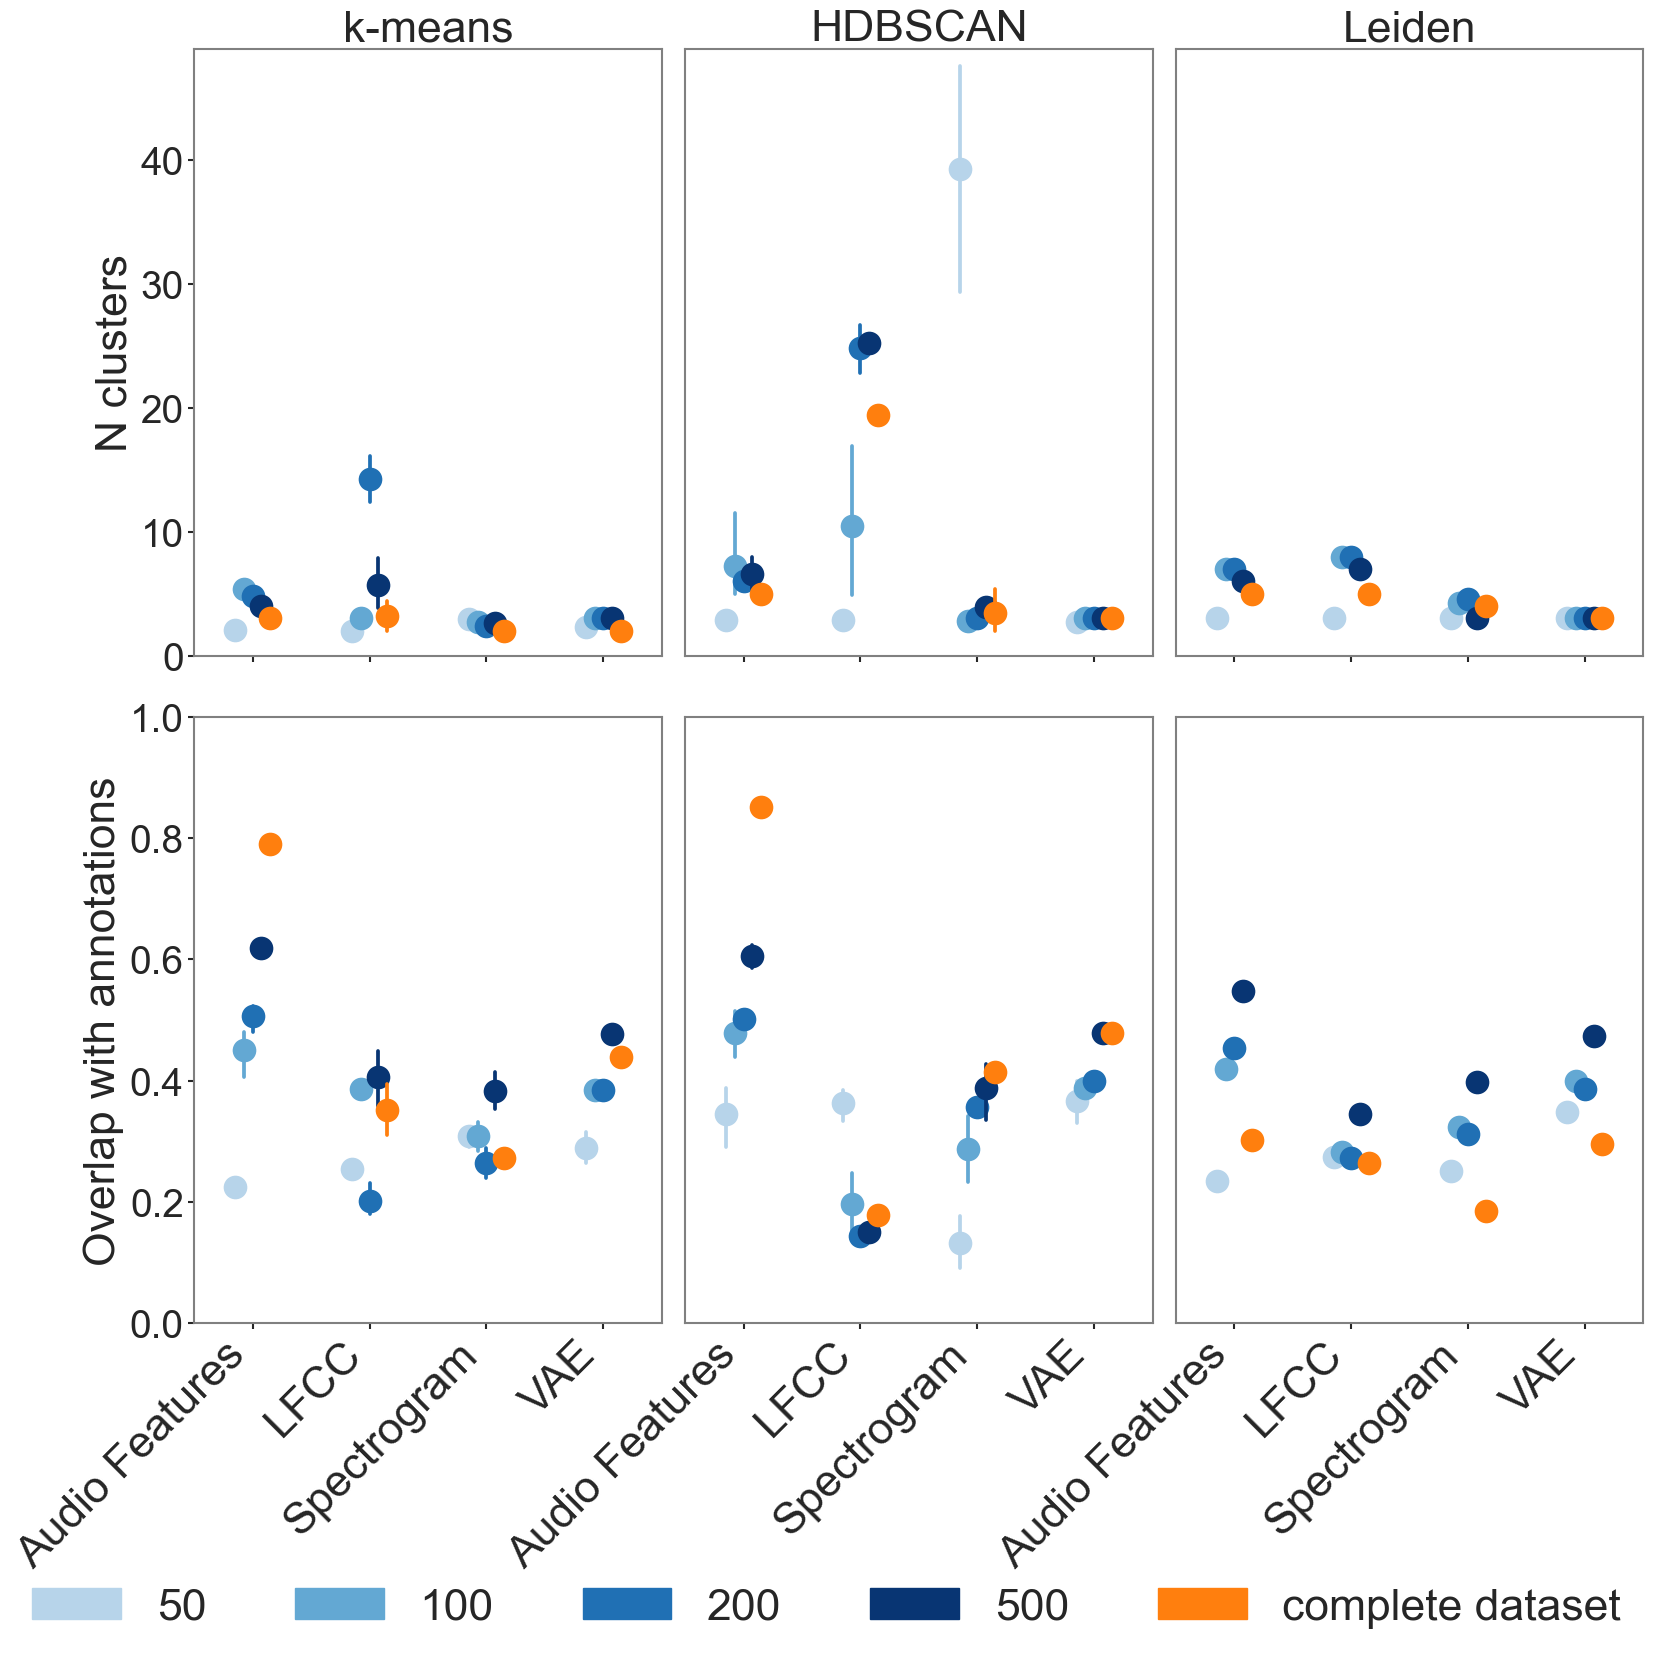

In [140]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 2)&(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["Audio Features", "LFCC", "Spectrogram", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, 1)
        else:
            axs[row, col].set_ylim(0, 49)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.21)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2080746171.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2080746171.py:54: UserWarning: set_tick

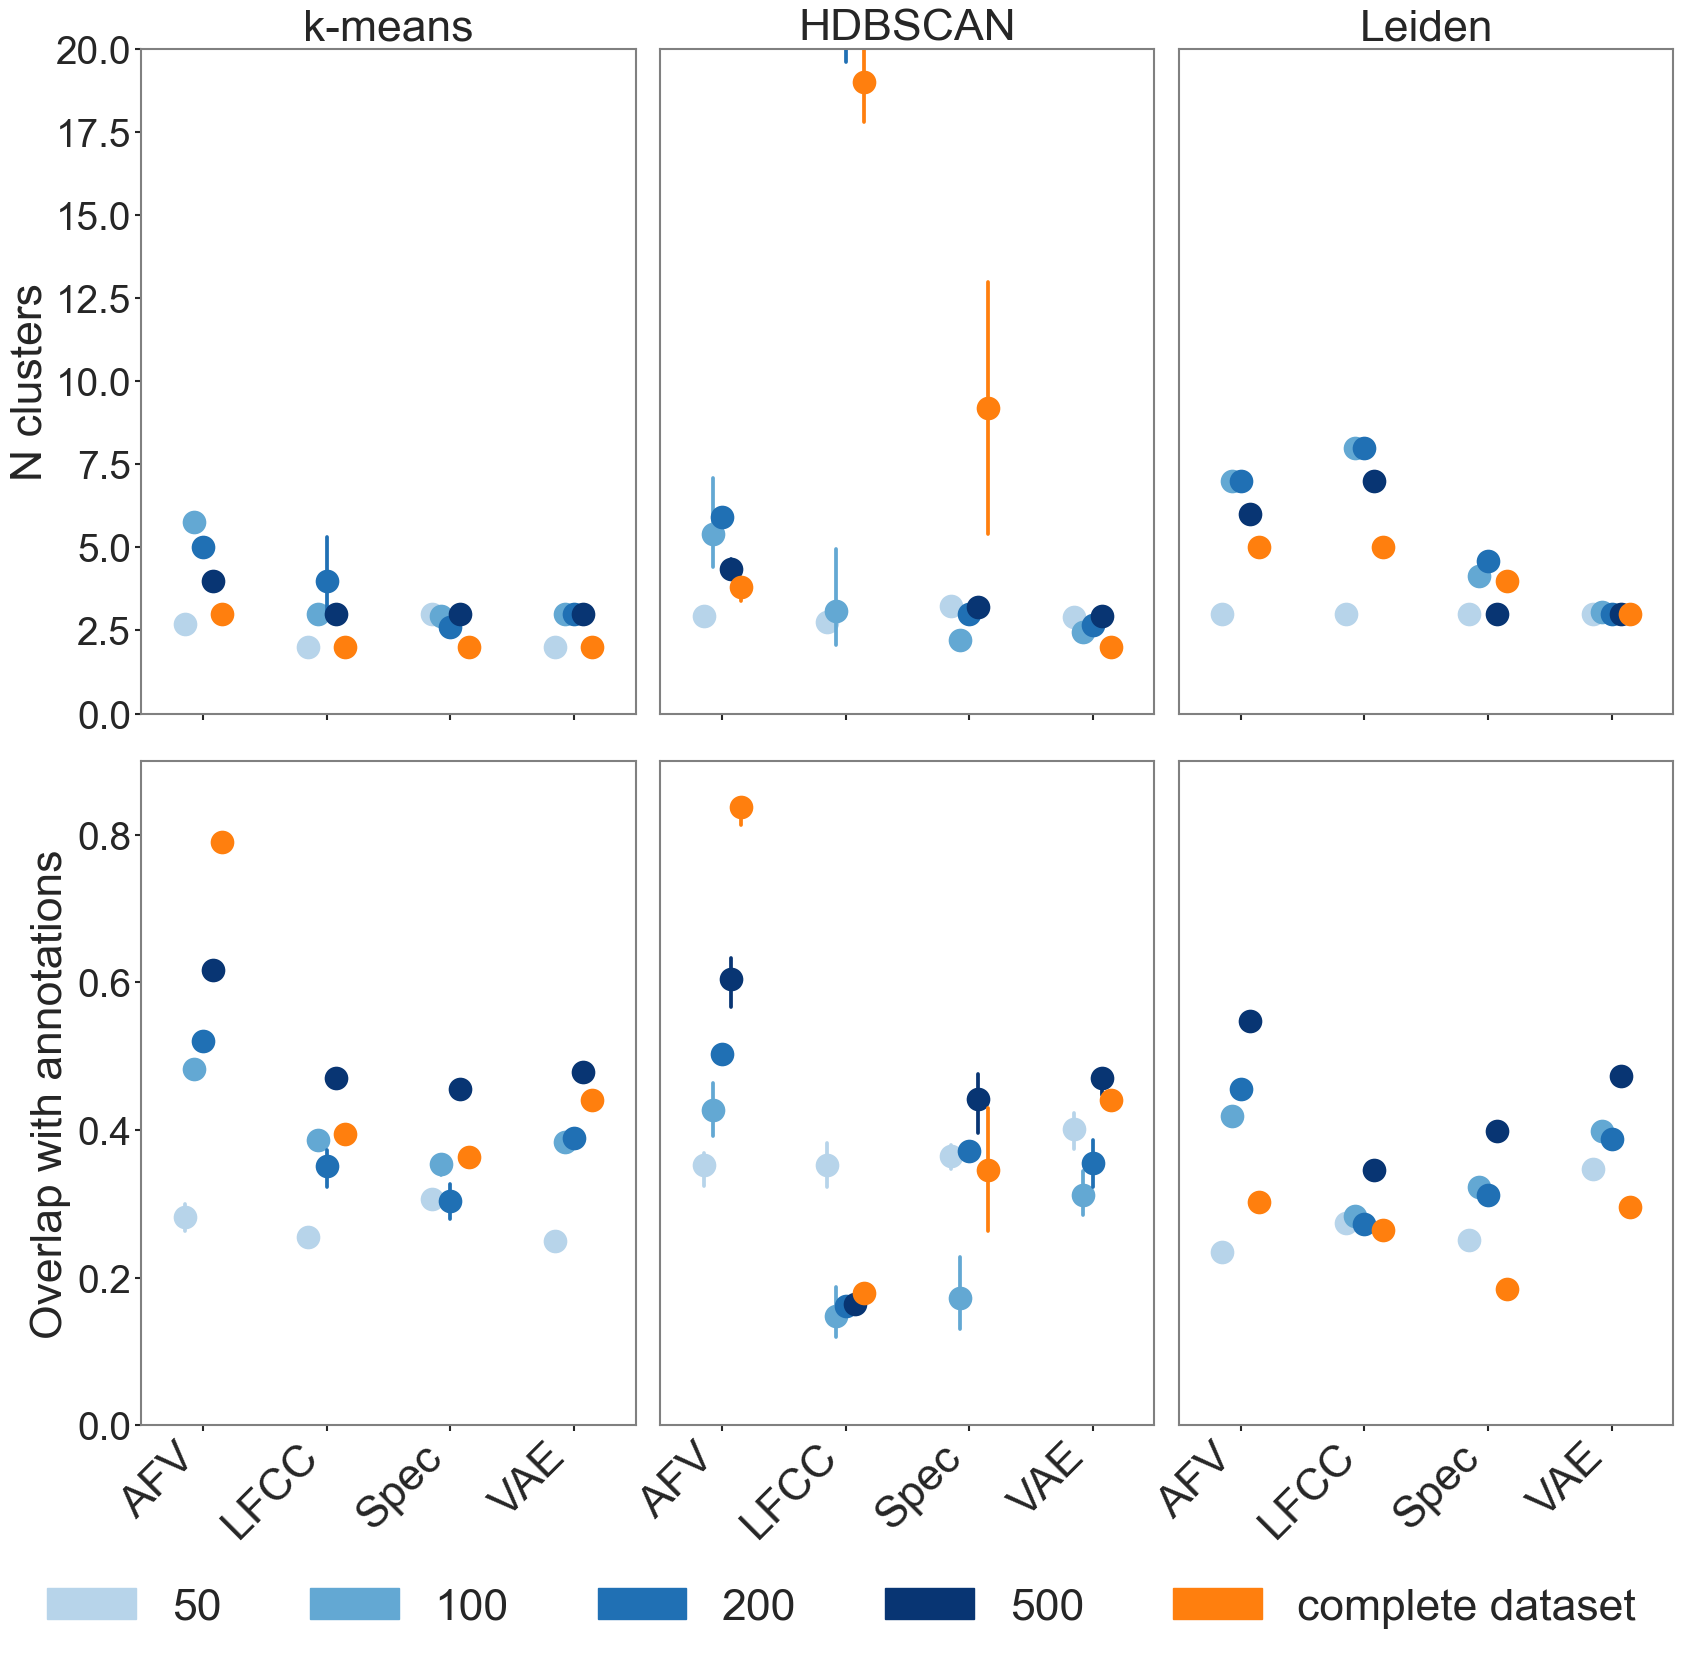

In [141]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 20) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/154244901.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/154244901.py:54: UserWarning: set_ticklabe

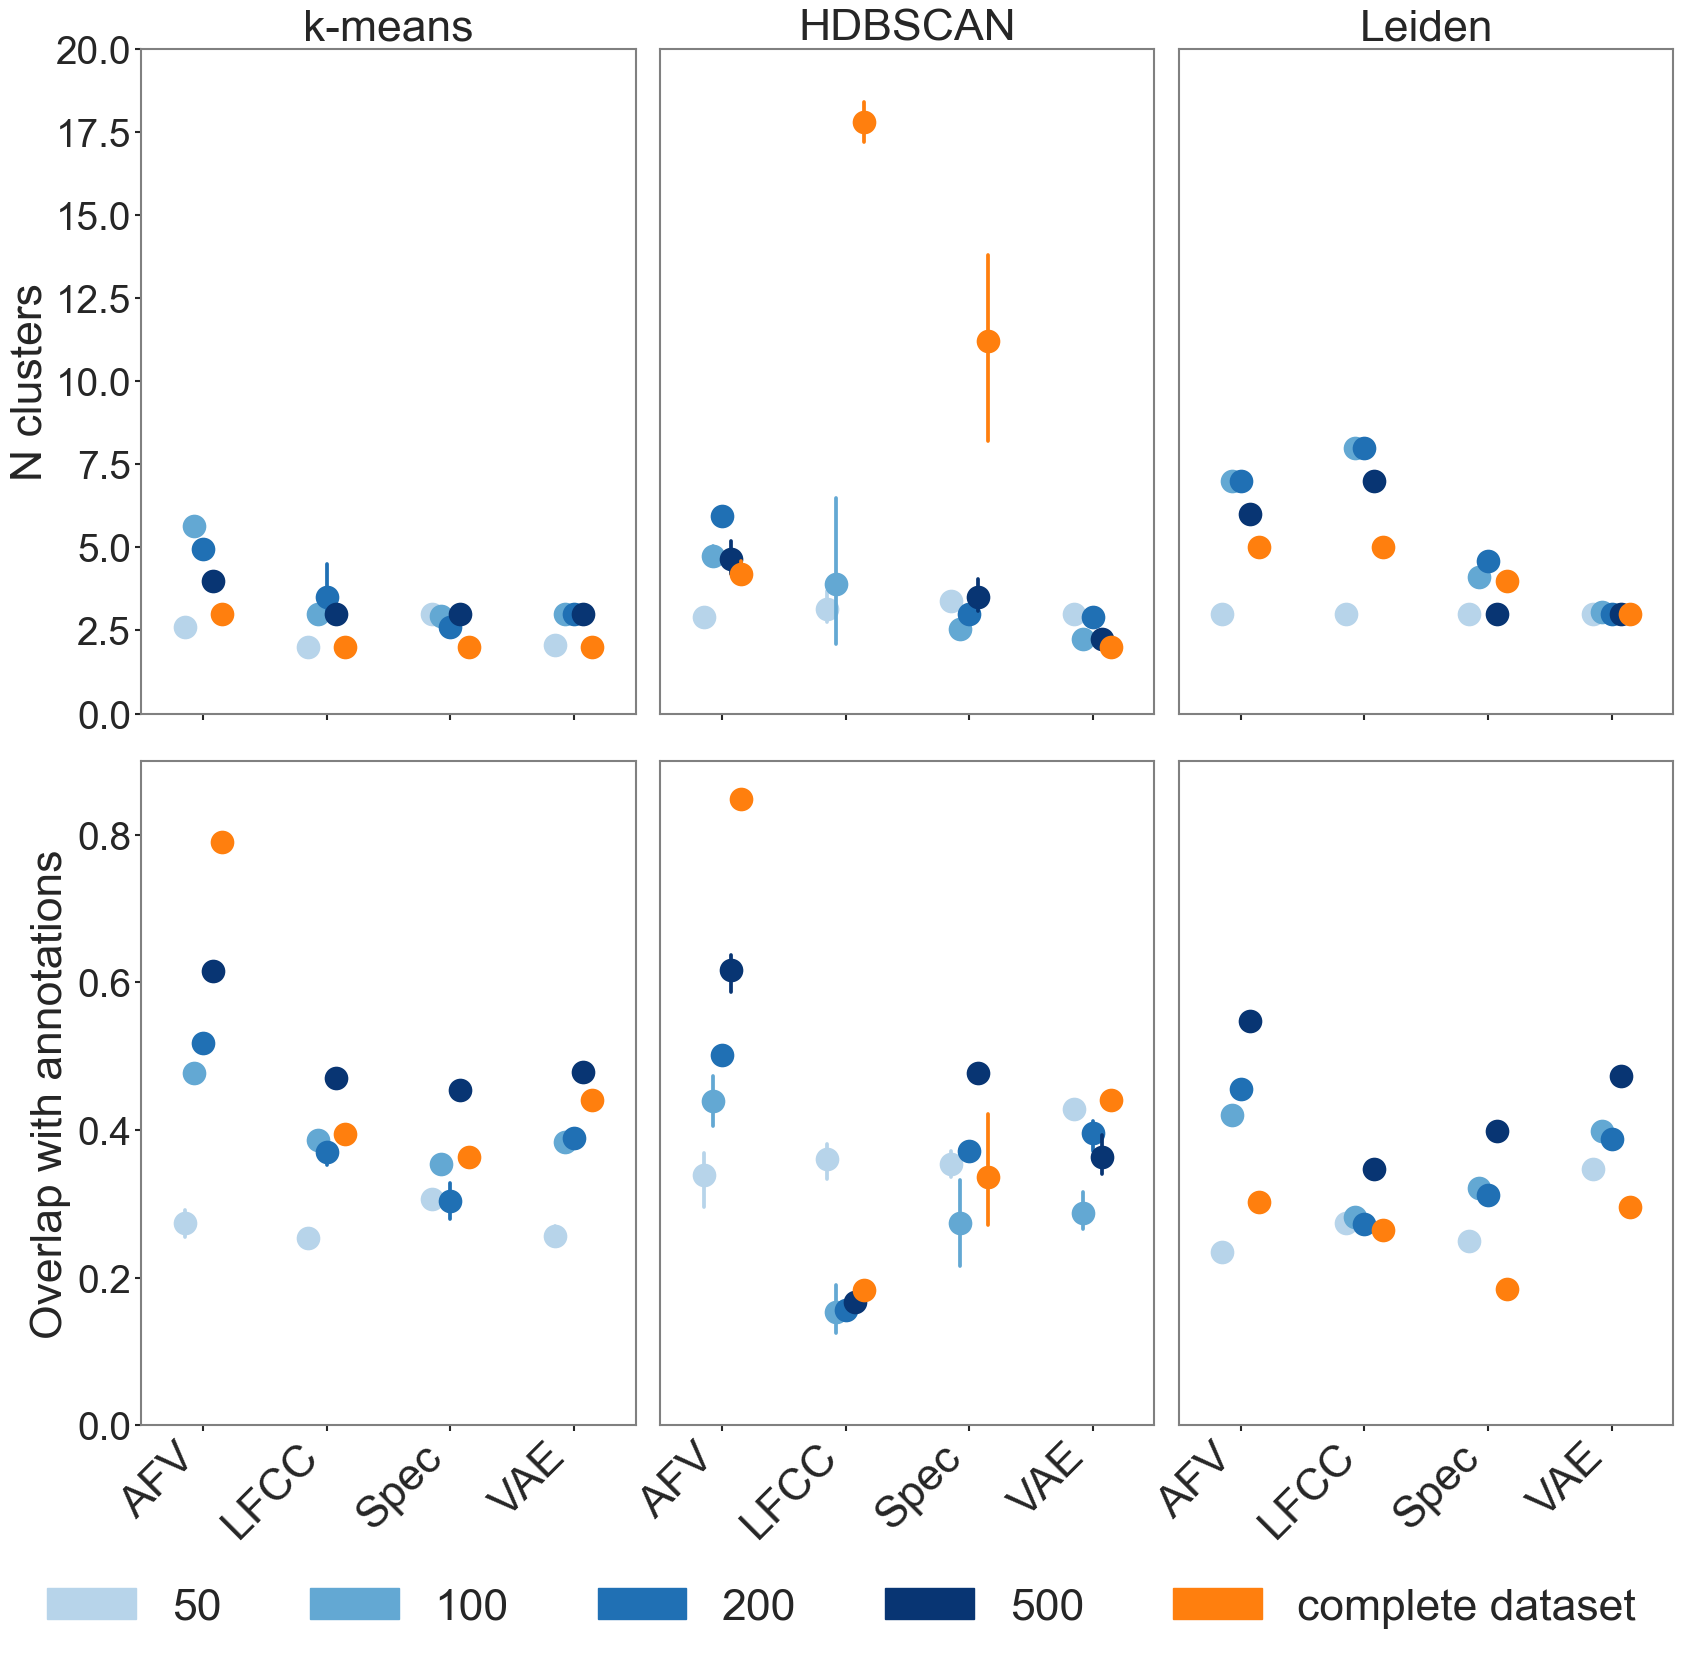

In [142]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["N clusters", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Dimensionality']== 100) & (results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Overlap with annotations", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, .9)
        else:
            axs[row, col].set_ylim(0, 20)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)

legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/874196049.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/874196049.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/874196049.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/874196049.py:54: UserWarning: set_ticklabe

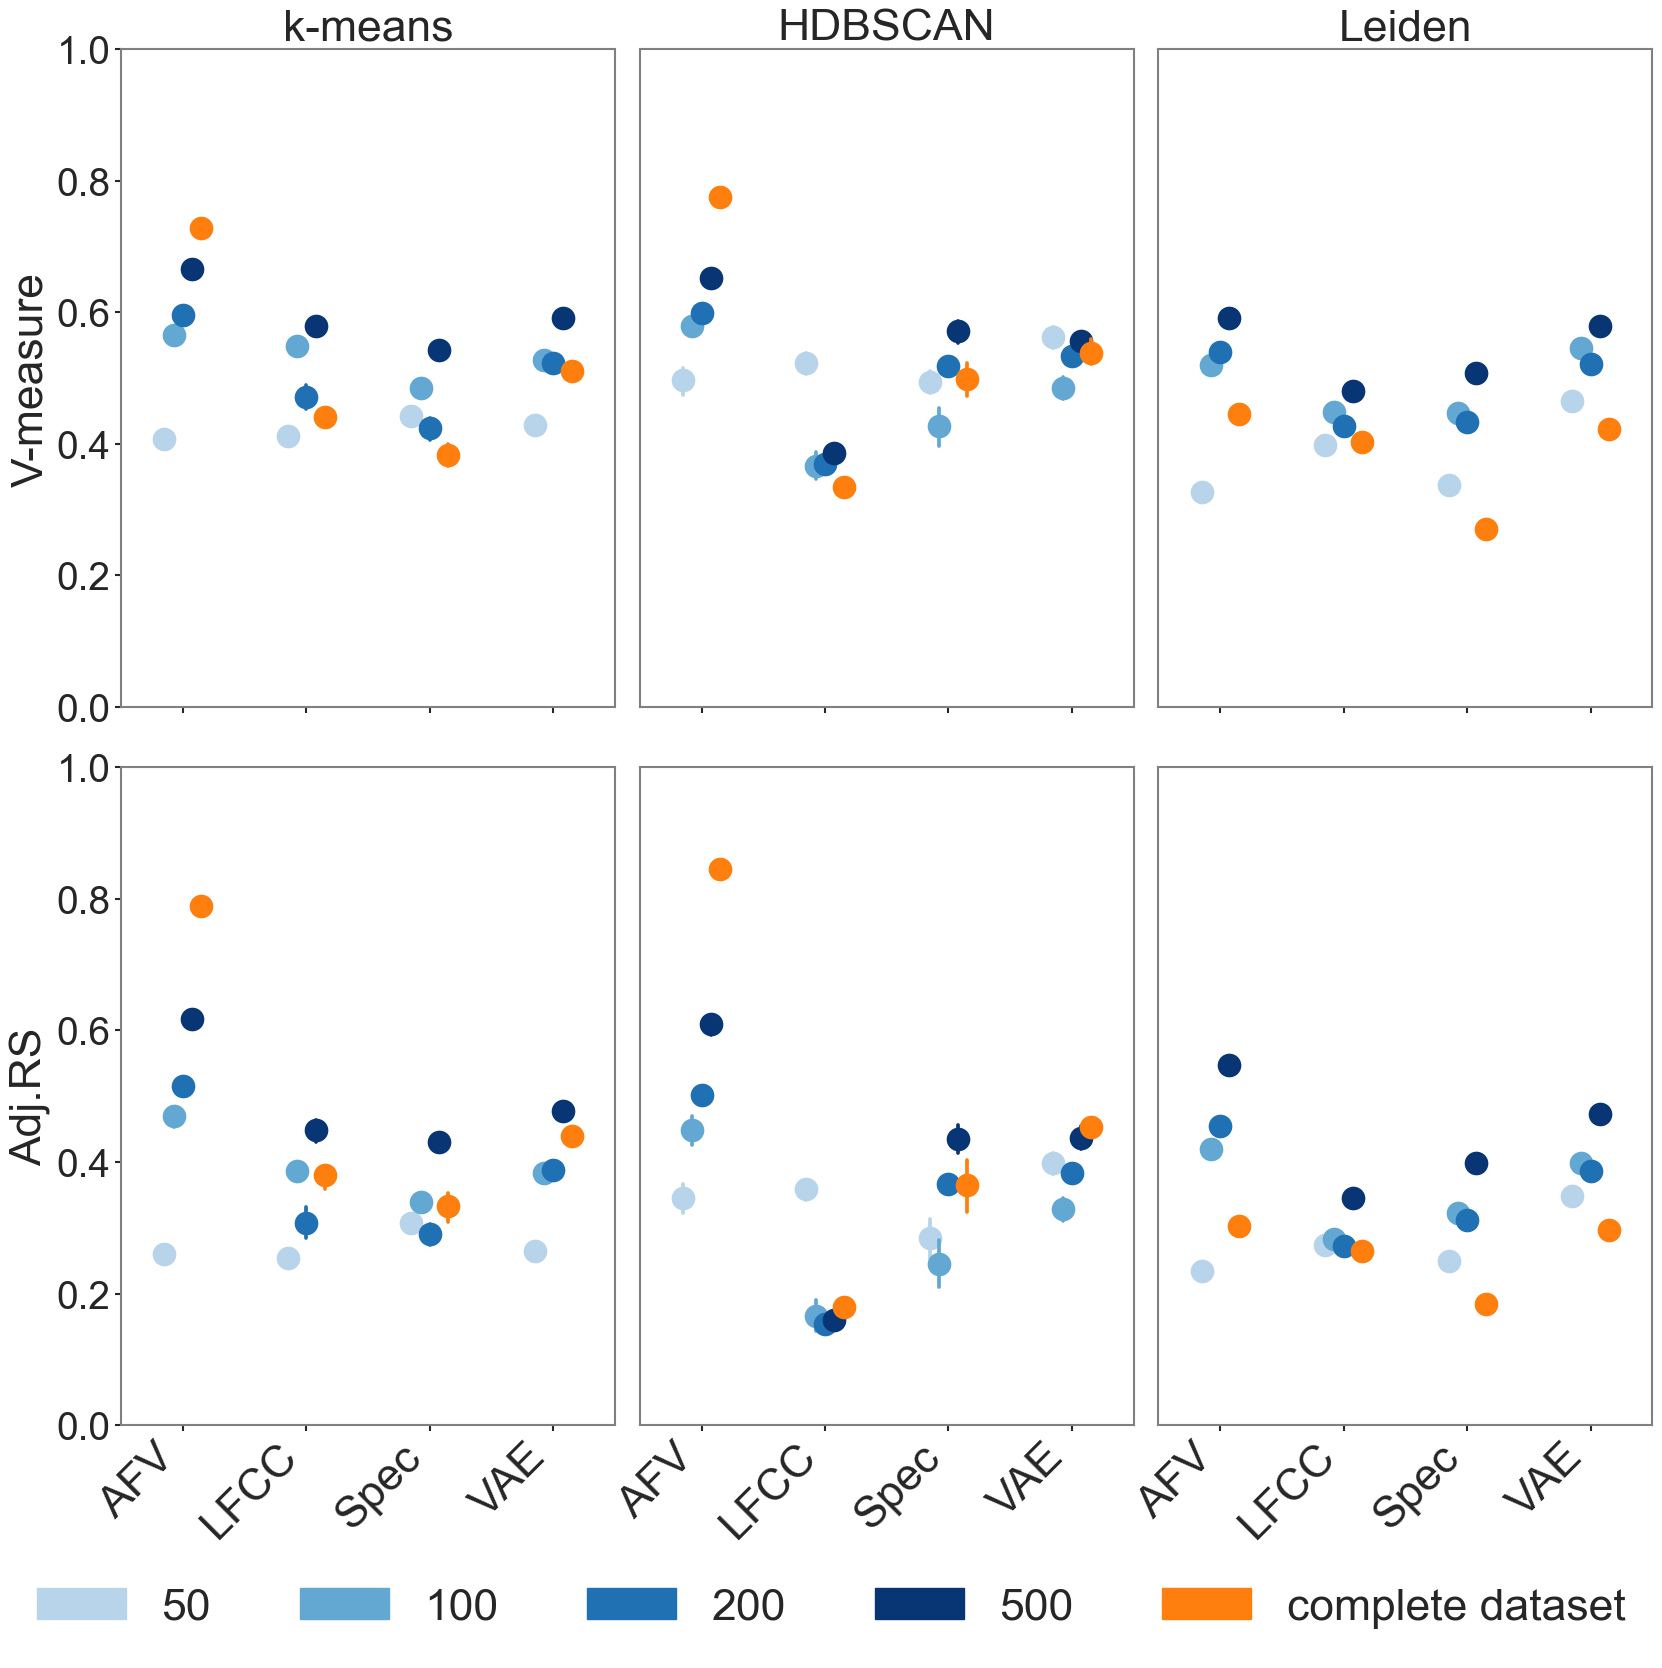

In [143]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

rows = ["V-measure", "Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spec", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(17, 17), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Representation']!="MFCC")]
for row, metric in enumerate(rows):
    for col, representation in enumerate(columns):
        data = sub_df[sub_df["Algorithm"] == representation]

        hue_levels_metric = data["Subset size"].unique()
        hue_levels = subset_labels
        tab20 = plt.get_cmap("tab20")
        blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

        palette = {
            50:  blues[0],   # darkest blue
            100: blues[1],
            200: blues[2],
            500: blues[3],   # lightest blue
            "complete dataset": tab20(2),  # tab20 orange
        }

        hue_col = "Subset size"

        sns.pointplot(
            x="Representation", 
            y=metric,  
            data=data, 
            ax=axs[row, col], 
            hue=hue_col,
            palette=palette,
            hue_order=hue_levels_metric,
            linestyle="none",
            alpha=1,
            errorbar="ci",
            dodge=.3,
            legend=False,
            markersize=15
        )

        axs[row, col].patch.set_alpha(0)
        if row == 0:
            axs[row, col].set_title(representation, fontsize=32)

        #axs[row, col].set_ylim(0.1, 0.7)
        axs[row, col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
        axs[row, col].set_xlabel("")
        axs[row, col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
        axs[row, col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

        if col == 0:
            axs[row, col].set_ylabel(metric, fontsize=32)  # Label only the first column
            if row == 1:
                axs[row, col].set_ylabel("Adj.RS", fontsize=32)
        else:
            axs[row, col].set_ylabel('')
            axs[row, col].set_yticks([])        
        
        if metric == "Adj. RS":
            axs[row, col].set_ylim(0, 1)
        else:
            axs[row, col].set_ylim(0, 1)
        
        for spine in axs[row, col].spines.values():
            spine.set_edgecolor('grey')
            spine.set_linewidth(1.5)


legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2940760926.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2940760926.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
/var/folders/22/8ybf3tsx6fd7rpm1r8j1tf8c0000gn/T/ipykernel_2507/2940760926.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')


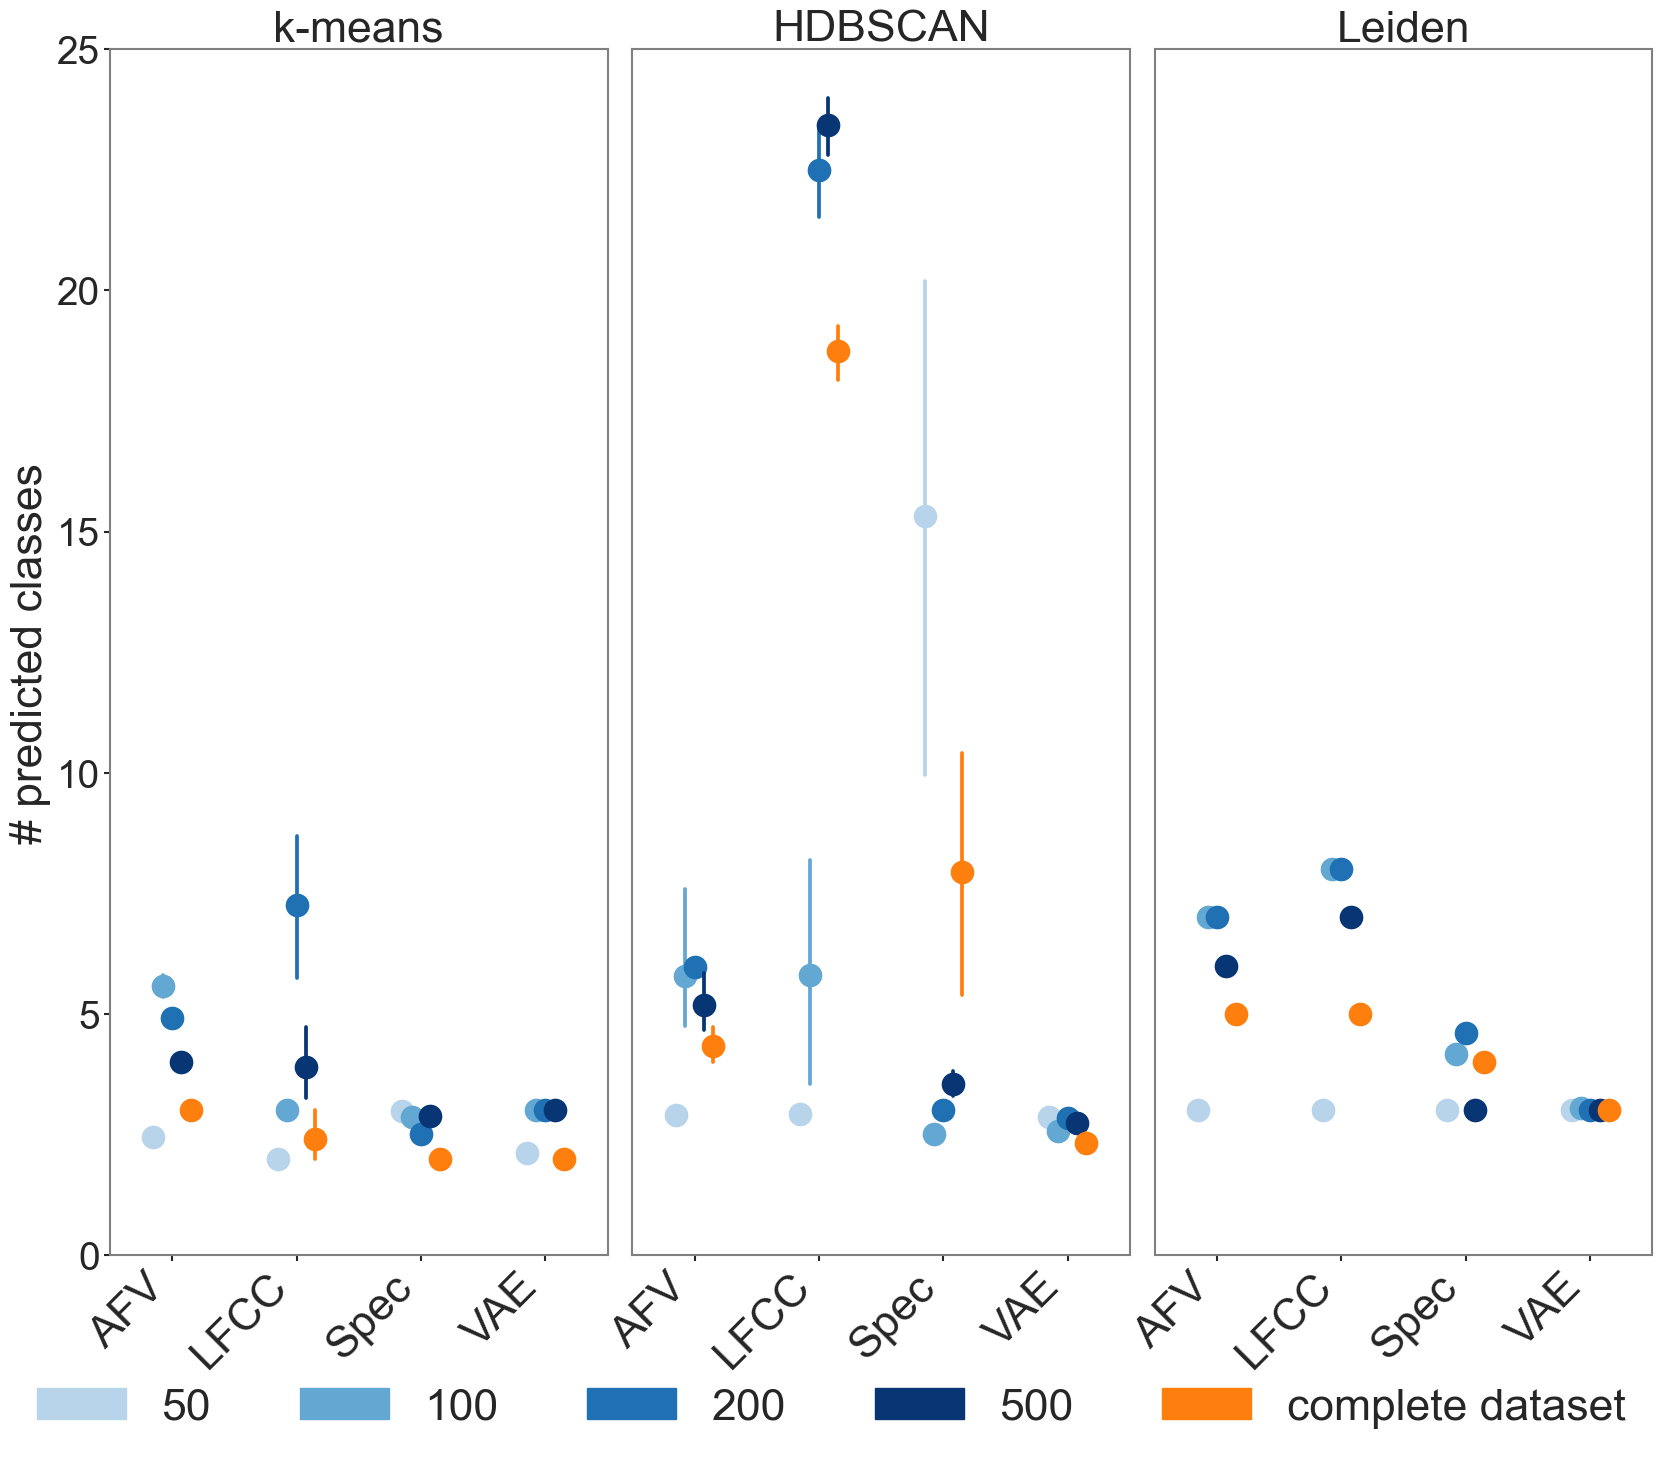

In [144]:
results_df['Subset size'] = results_df['Subset size'].replace(4000, 'complete dataset')

columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["AFV", "LFCC", "Spectrogram", "VAE"]

subset_labels = results_df["Subset size"].unique()
subset_labels = ['complete dataset' if x == 4000 else x for x in subset_labels]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(17, 15), sharex=True, sharey=False)
fig.patch.set_alpha(0)  # figure background transparent

sub_df = results_df[(results_df['Representation']!="MFCC")]

for col, representation in enumerate(columns):
    data = sub_df[sub_df["Algorithm"] == representation]

    hue_levels_metric = data["Subset size"].unique()
    hue_levels = subset_labels
    tab20 = plt.get_cmap("tab20")
    blues = plt.get_cmap("Blues")(np.linspace(0.3, 0.98, 4))  # lighter to darker blues

    palette = {
        50:  blues[0],   # darkest blue
        100: blues[1],
        200: blues[2],
        500: blues[3],   # lightest blue
        "complete dataset": tab20(2),  # tab20 orange
    }

    hue_col = "Subset size"

    sns.pointplot(
        x="Representation", 
        y="N clusters",  
        data=data, 
        ax=axs[col], 
        hue=hue_col,
        palette=palette,
        hue_order=hue_levels_metric,
        linestyle="none",
        alpha=1,
        errorbar="ci",
        dodge=.3,
        legend=False,
        markersize=15
    )

    axs[col].patch.set_alpha(0)
    axs[col].set_title(representation, fontsize=32)

    #axs[row, col].set_ylim(0.1, 0.7)
    axs[col].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right')
    axs[col].set_xlabel("")
    axs[col].tick_params(axis="y", which="major", labelsize=28, length=4, width=1.5,)# color="grey")
    axs[col].tick_params(axis="x", which="major", labelsize=32, length=4, width=1.5,)# color="grey")

    if col == 0:
        axs[col].set_ylabel("# predicted classes", fontsize=32)  # Label only the first column
    else:
        axs[col].set_ylabel('')
        axs[col].set_yticks([])        
    
    axs[col].set_ylim(0, 25)
    
    for spine in axs[col].spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(1.5)


legend_handles = [Patch(color=palette[level], label=str(level)) for level in hue_levels]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=len(legend_handles), # one row
    fontsize=32,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.15)
plt.subplots_adjust(wspace=0.05)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


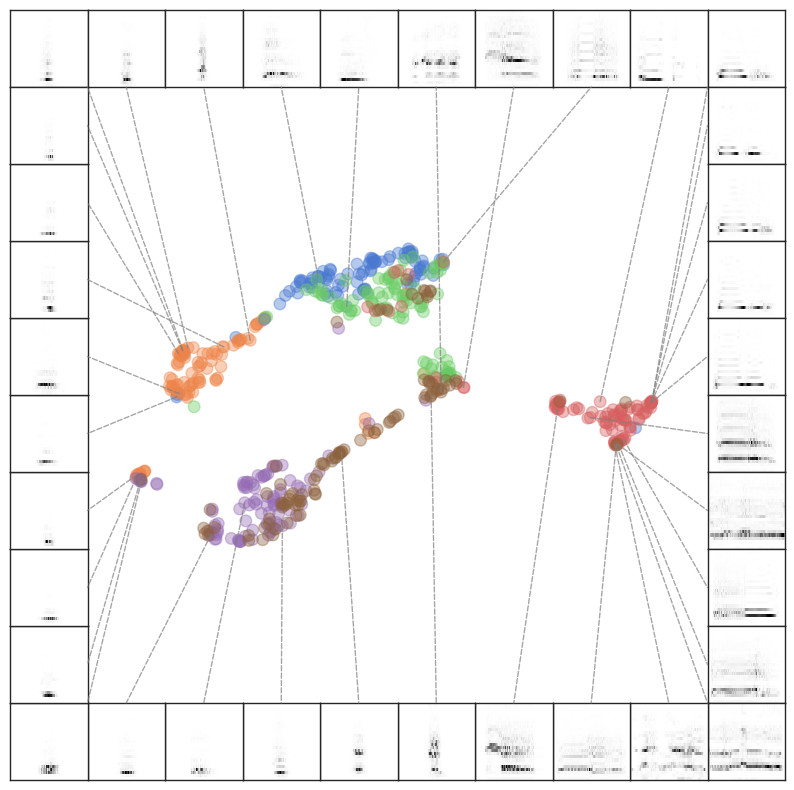

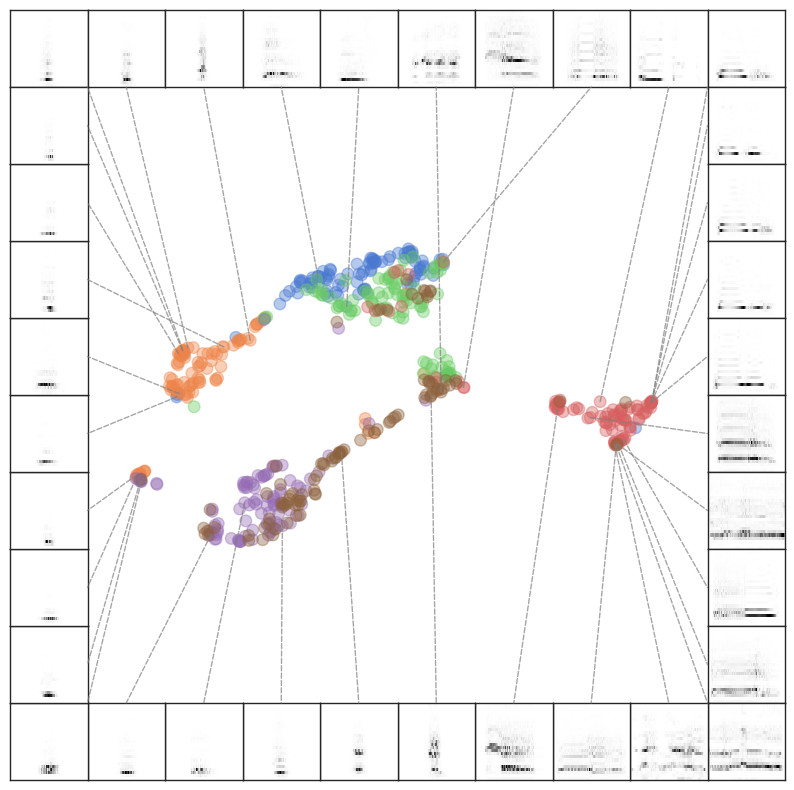

In [145]:
vis_data_sub = vis_data[0][0]
scatter_spec(
    vis_data_sub["embeddings"]["paf"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"],
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


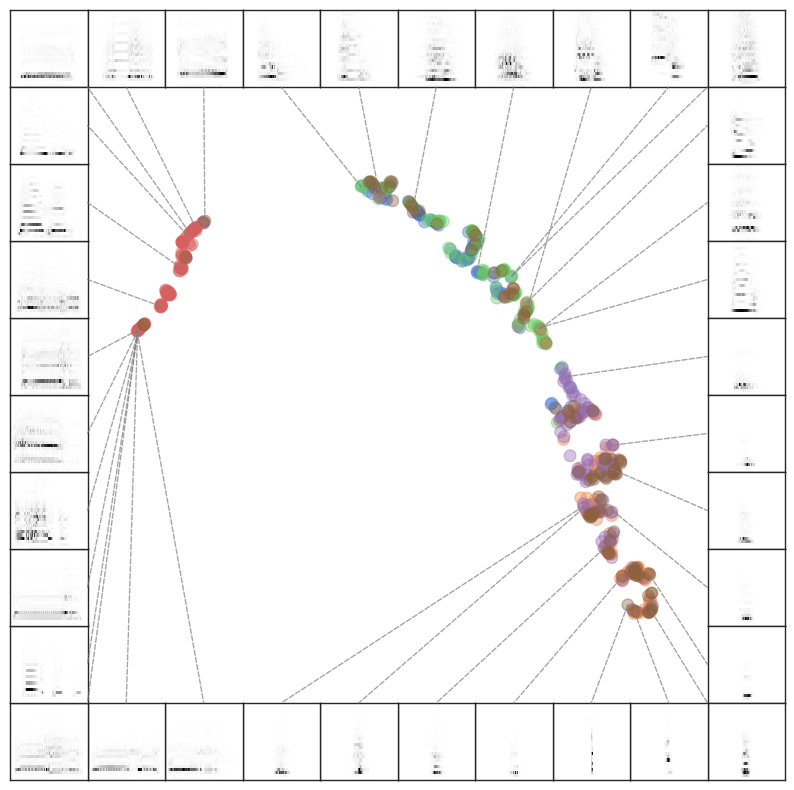

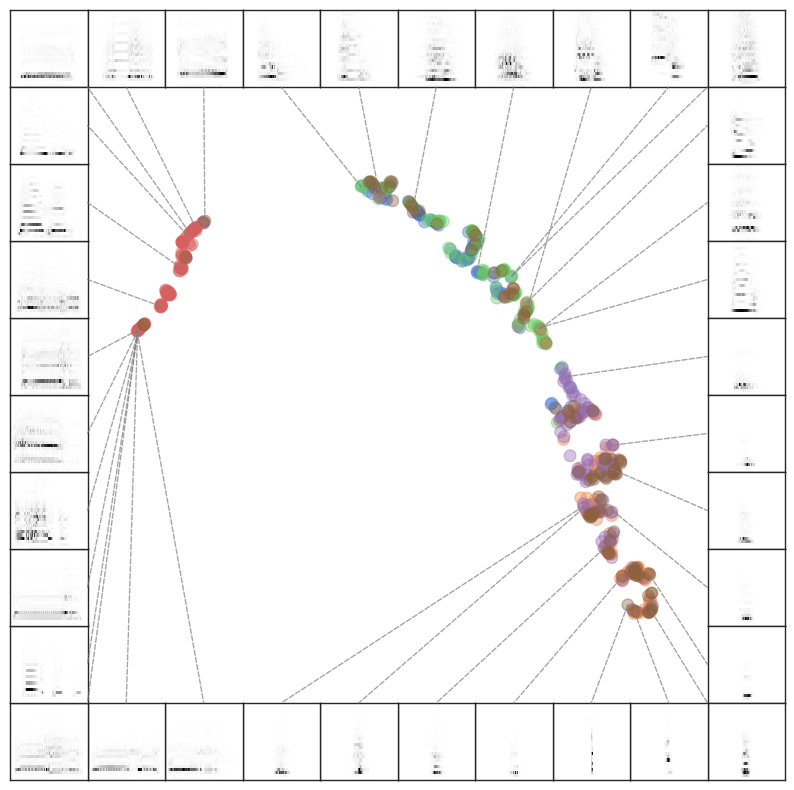

In [146]:
scatter_spec(
    vis_data_sub["embeddings"]["lfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


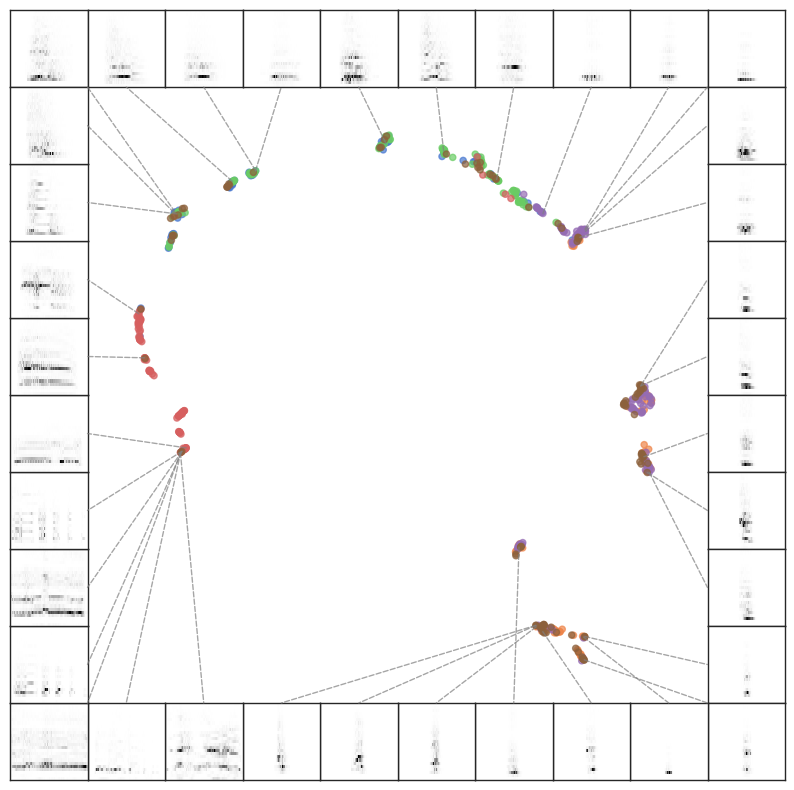

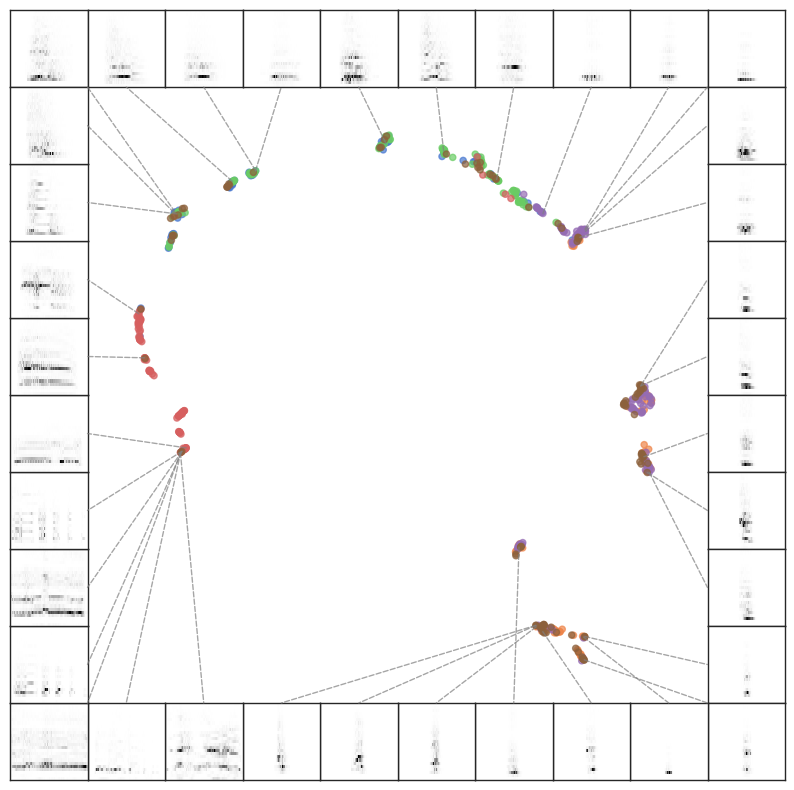

In [147]:
scatter_spec(
    vis_data_sub["embeddings"]["mfcc"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.7, "s": 20, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


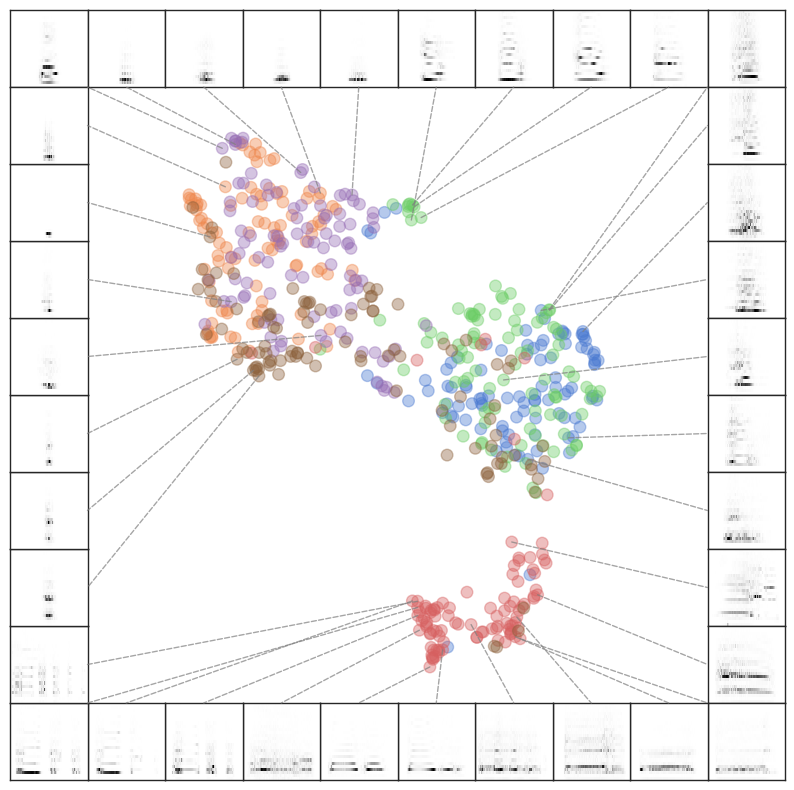

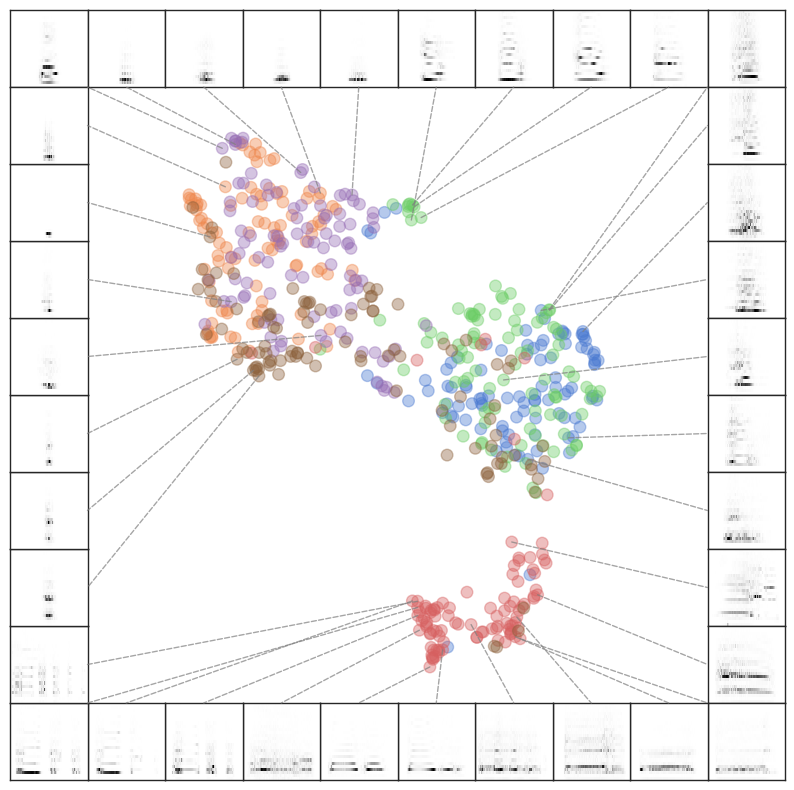

In [148]:
scatter_spec(
    vis_data_sub["embeddings"]["spec"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


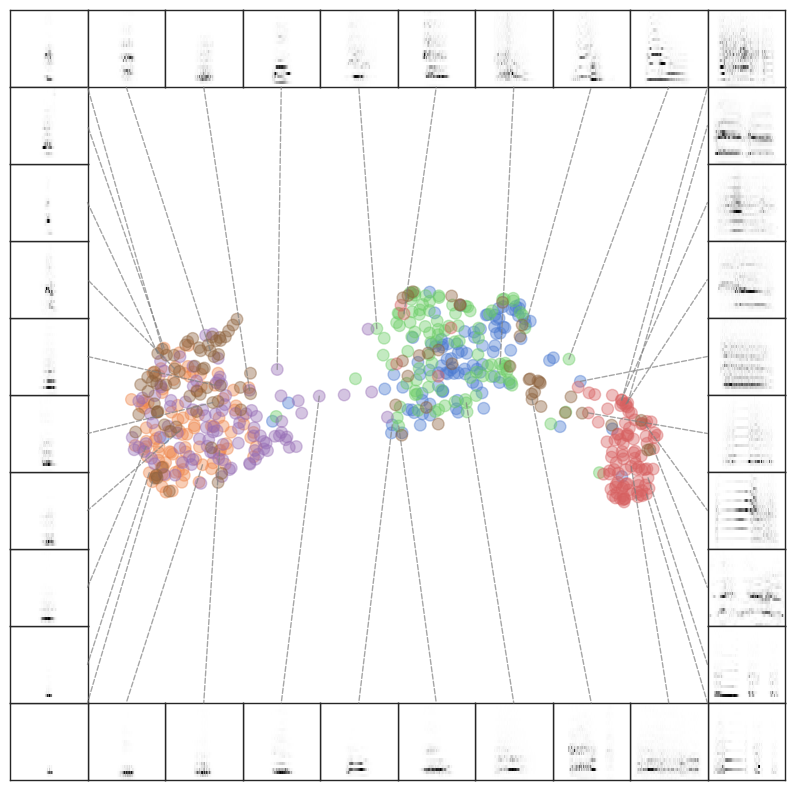

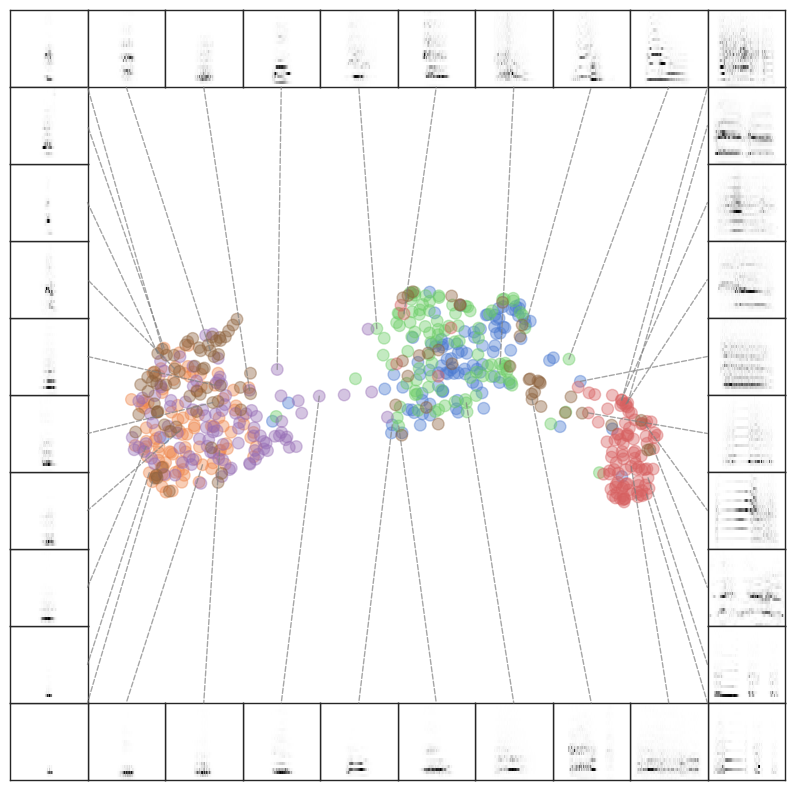

In [149]:
scatter_spec(
    vis_data_sub["embeddings"]["vae"], 
    vis_data_sub["subset_df"]["log_padded_spectrogram"], 
    scatter_kwargs={"alpha": 0.4, "s": 70, "labels": vis_data_sub["subset_df"]["Call Type"], "show_legend": False, "figsize": (5,5)},    
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 0.7, "color": "gray"},
)

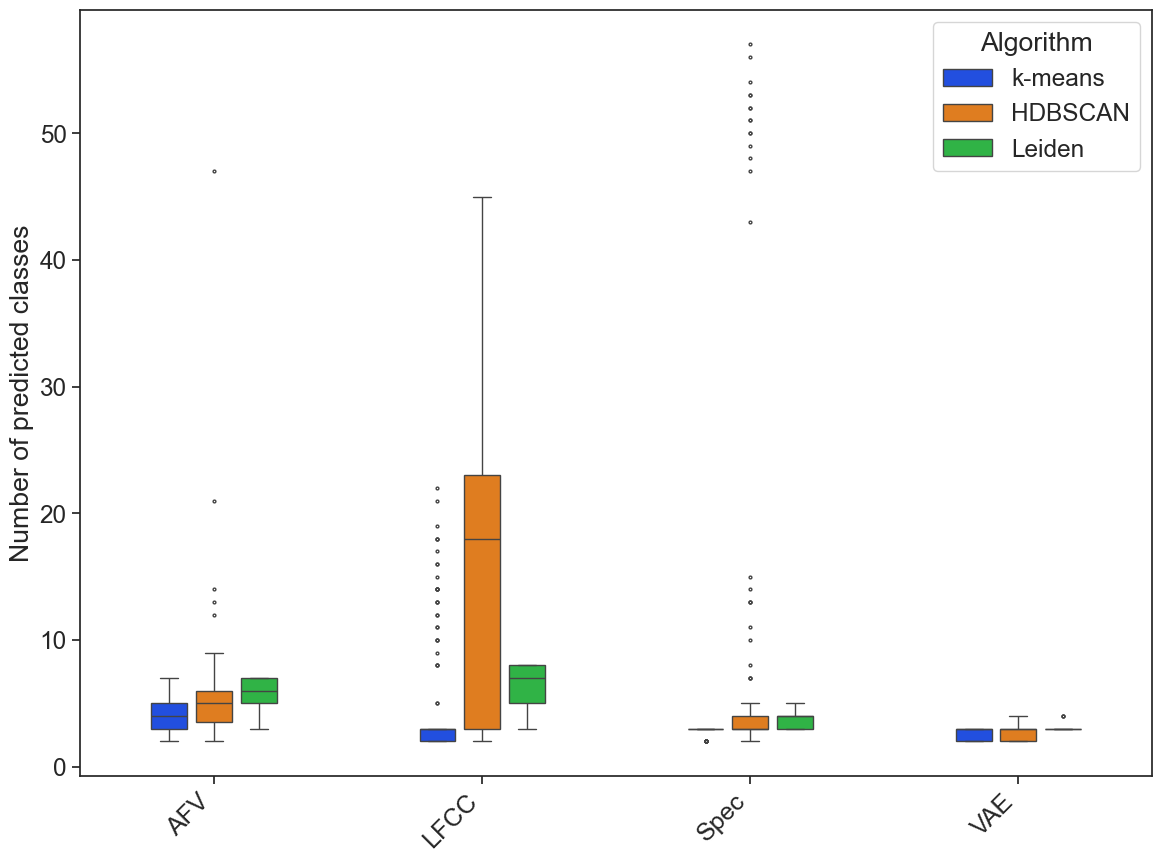

In [150]:
fig, ax = plt.subplots(ncols=1, figsize=(12, 9))

sns.boxplot(
    x="Representation", 
    y="N clusters", 
    data=results_df[(results_df['Representation']!="MFCC")], 
    ax=ax, 
    hue="Algorithm", 
    legend=True,
    gap=.2,
    fliersize=2,
    width=.5,
    palette="bright"
)

ax.set_xticks(range(len(["AFV", "LFCC", "Spec", "VAE"])))
ax.set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right', fontsize=18)
# ax.set_title("N clusters", fontsize=24)
ax.set_ylabel('Number of predicted classes')
ax.set_xlabel('')
# ax.set_ylim(0, .9)

plt.tight_layout()
plt.show()


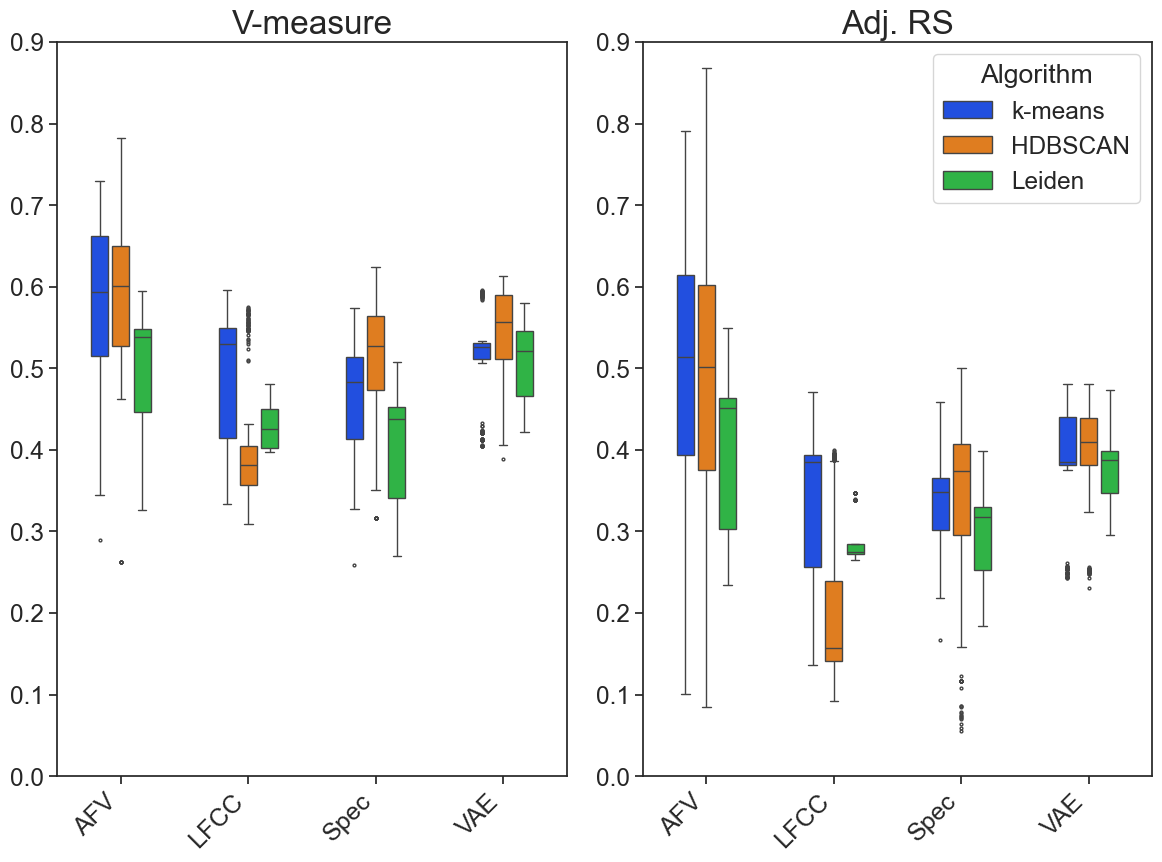

In [151]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 9))

columns = ["V-measure", "Adj. RS"]
for i, column in enumerate(columns):
    sns.boxplot(
        x="Representation", 
        y=column, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(columns)-1 else False,
        gap=.2,
        fliersize=2,
        width=.5,
        palette="bright"
    )
    
    axs[i].set_xticks(range(len(["AFV", "LFCC", "Spec", "VAE"])))
    axs[i].set_xticklabels(["AFV", "LFCC", "Spec", "VAE"], rotation=45, ha='right', fontsize=18)
    axs[i].set_title(column, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_ylim(0, .9)

plt.tight_layout()
plt.show()


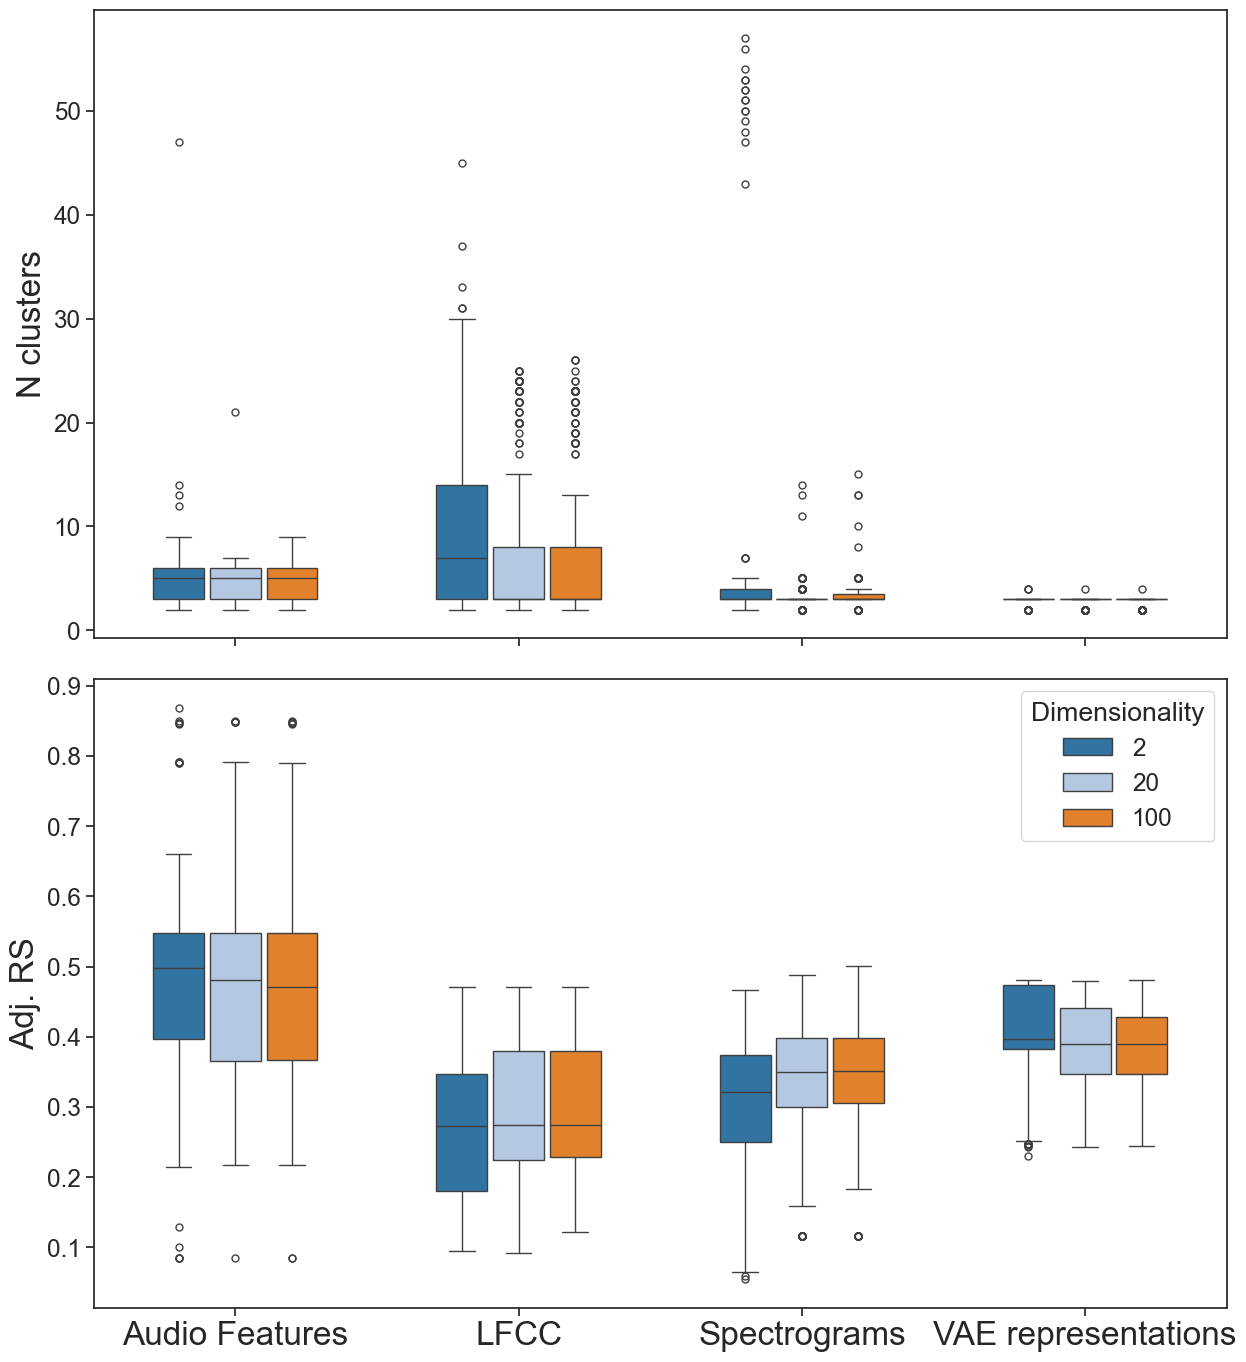

In [152]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Dimensionality", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


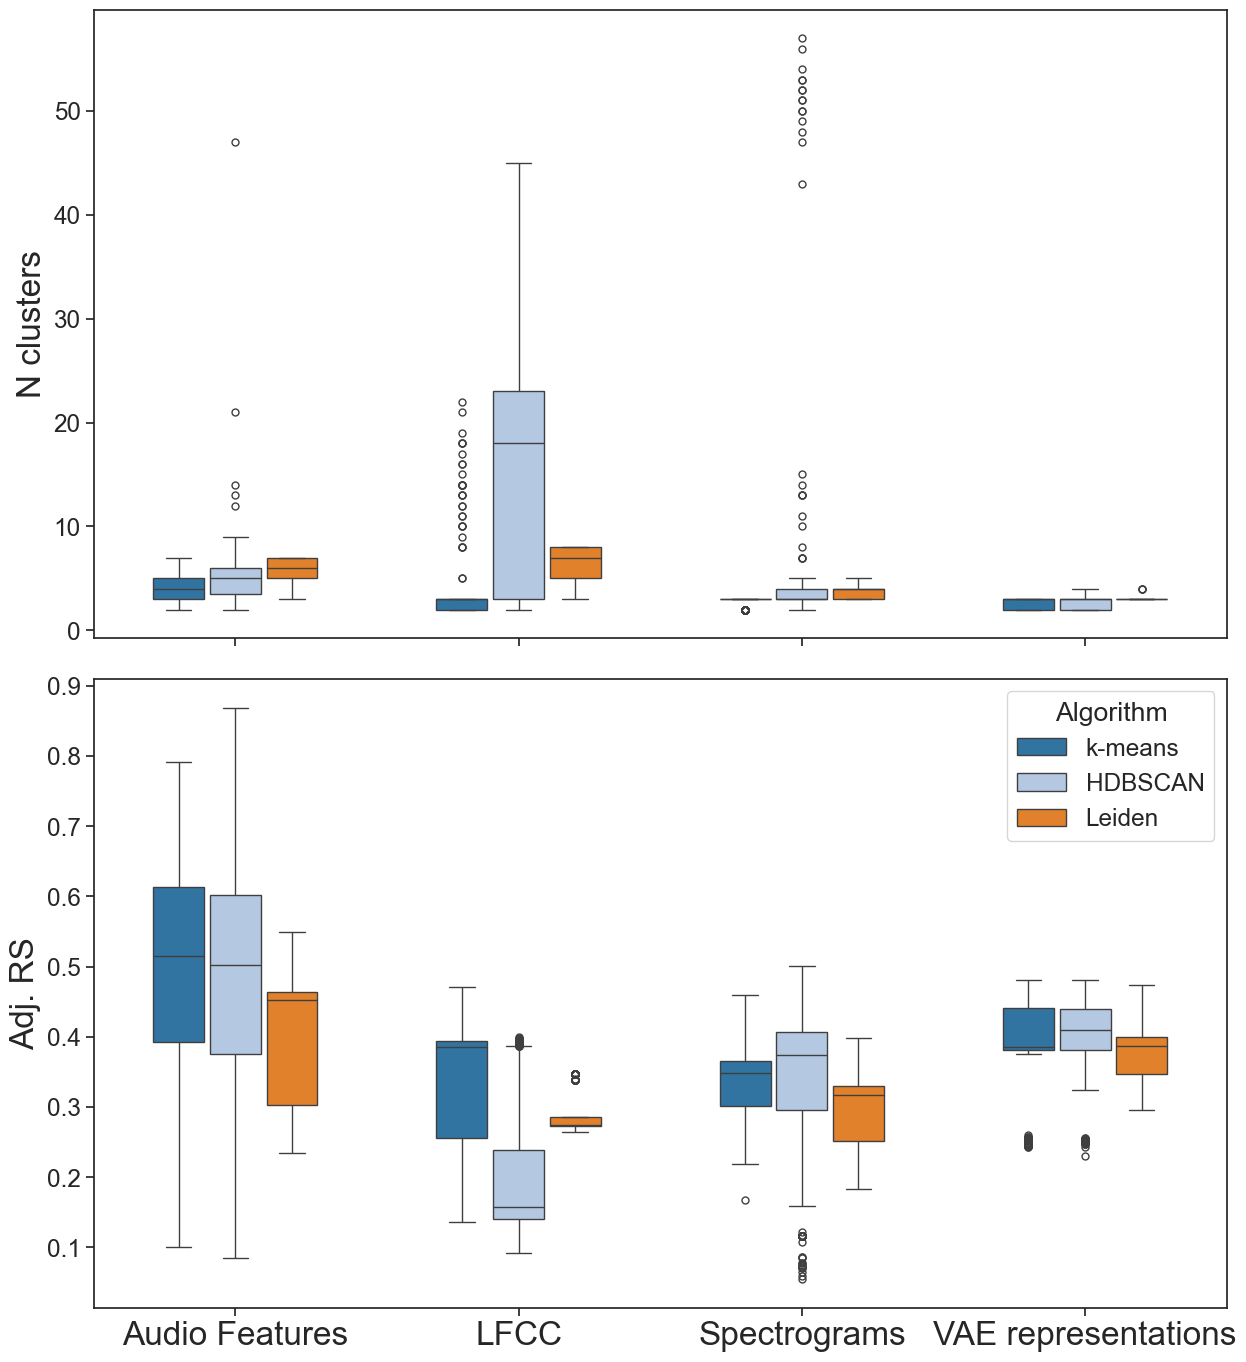

In [153]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(13, 14))

rows = ["N clusters", "Adj. RS"]
for i, row in enumerate(rows):
    sns.boxplot(
        x="Representation", 
        y=row, 
        data=results_df[(results_df['Representation']!="MFCC")], 
        ax=axs[i], 
        hue="Algorithm", 
        legend=True if i == len(rows)-1 else False,
        gap=.1,
        fliersize=5,
        width=.6,
        palette="tab20"
    )
    
    axs[i].set_xticks(range(len(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'])))
    if i==1:
        axs[i].set_xticklabels(['Audio Features', 'LFCC', 'Spectrograms', 'VAE representations'], fontsize=24)#ha='right',rotation=45,
    else:
        axs[i].set_xticklabels("")
    # axs[i].set_title(row, fontsize=24)
    axs[i].set_xlabel('')
    axs[i].set_ylabel(row, fontsize=24)
    # axs[i].set_ylim(.0, .85)

plt.tight_layout()
plt.show()


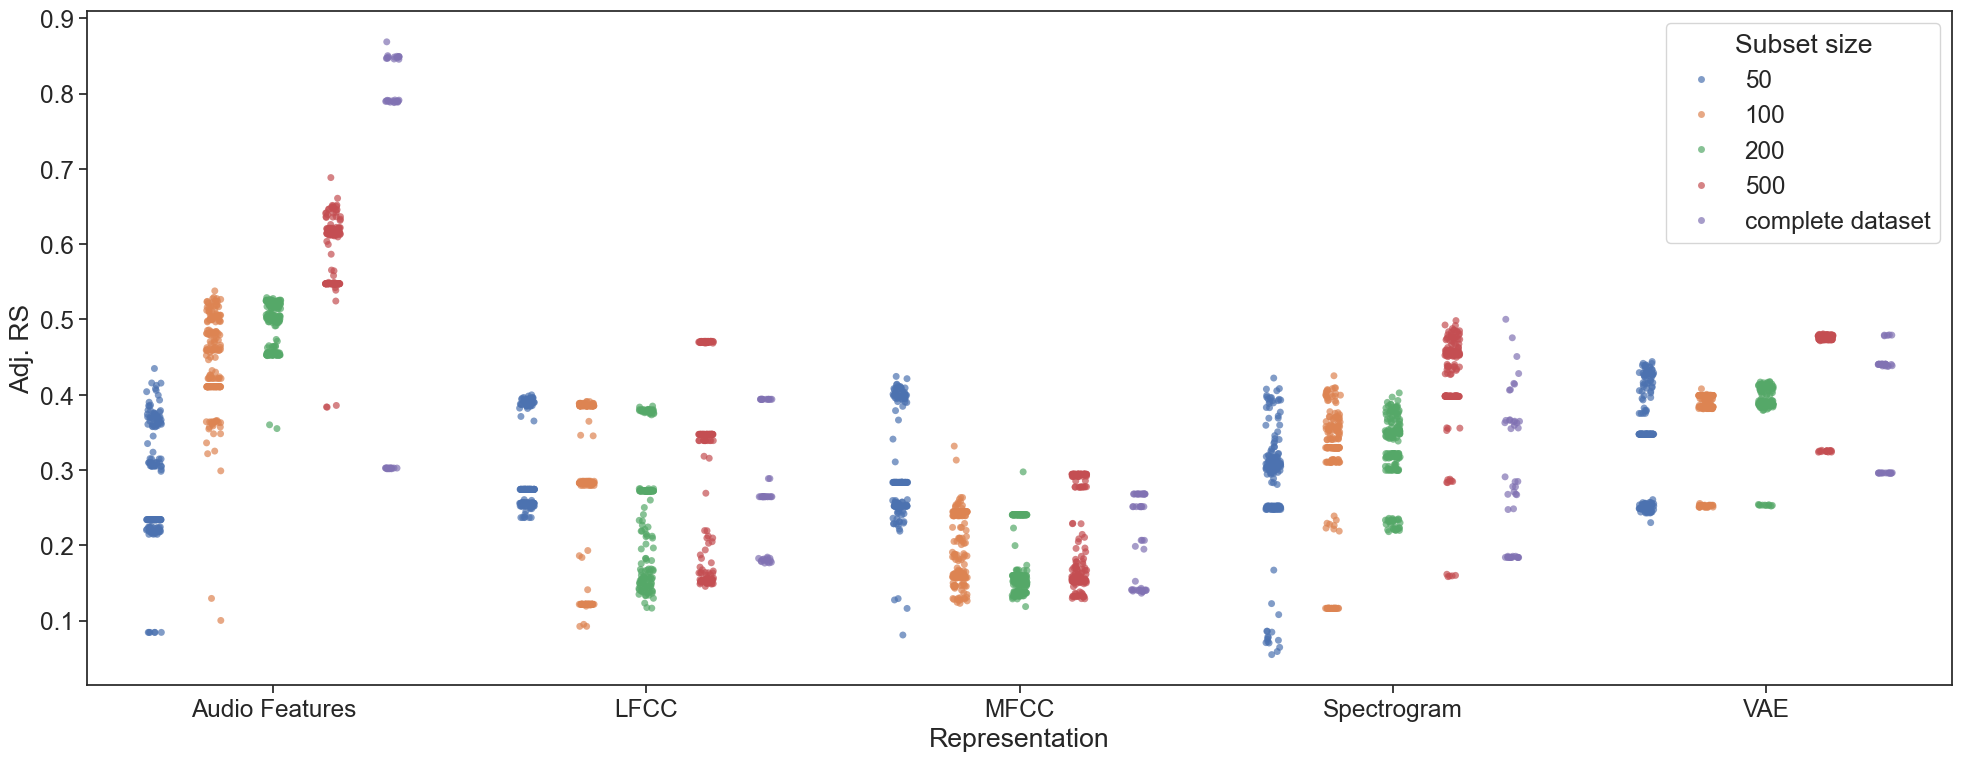

In [154]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Representation", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

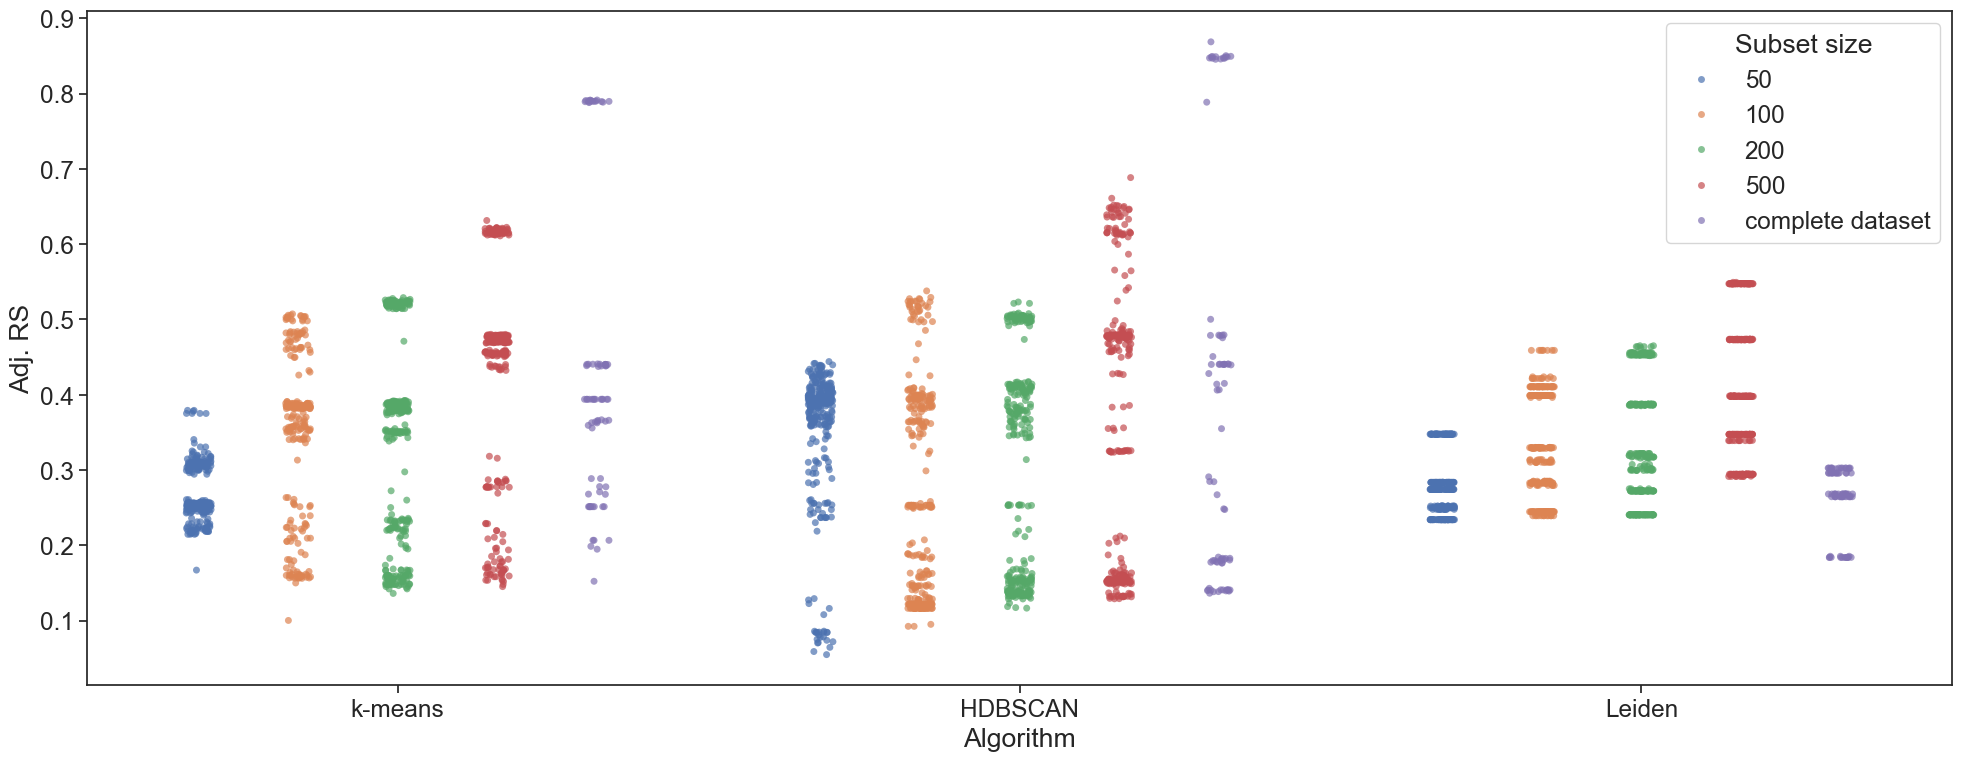

In [155]:
rows = ["Adj. RS"]
columns = ["k-means", "HDBSCAN", "Leiden"]
representations = ["PAF", "LFCC", "Spectrogram", "VAE"]

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Algorithm", 
    y="Adj. RS",  
    data=results_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=.3,
    legend=True
)
plt.tight_layout()
plt.show()

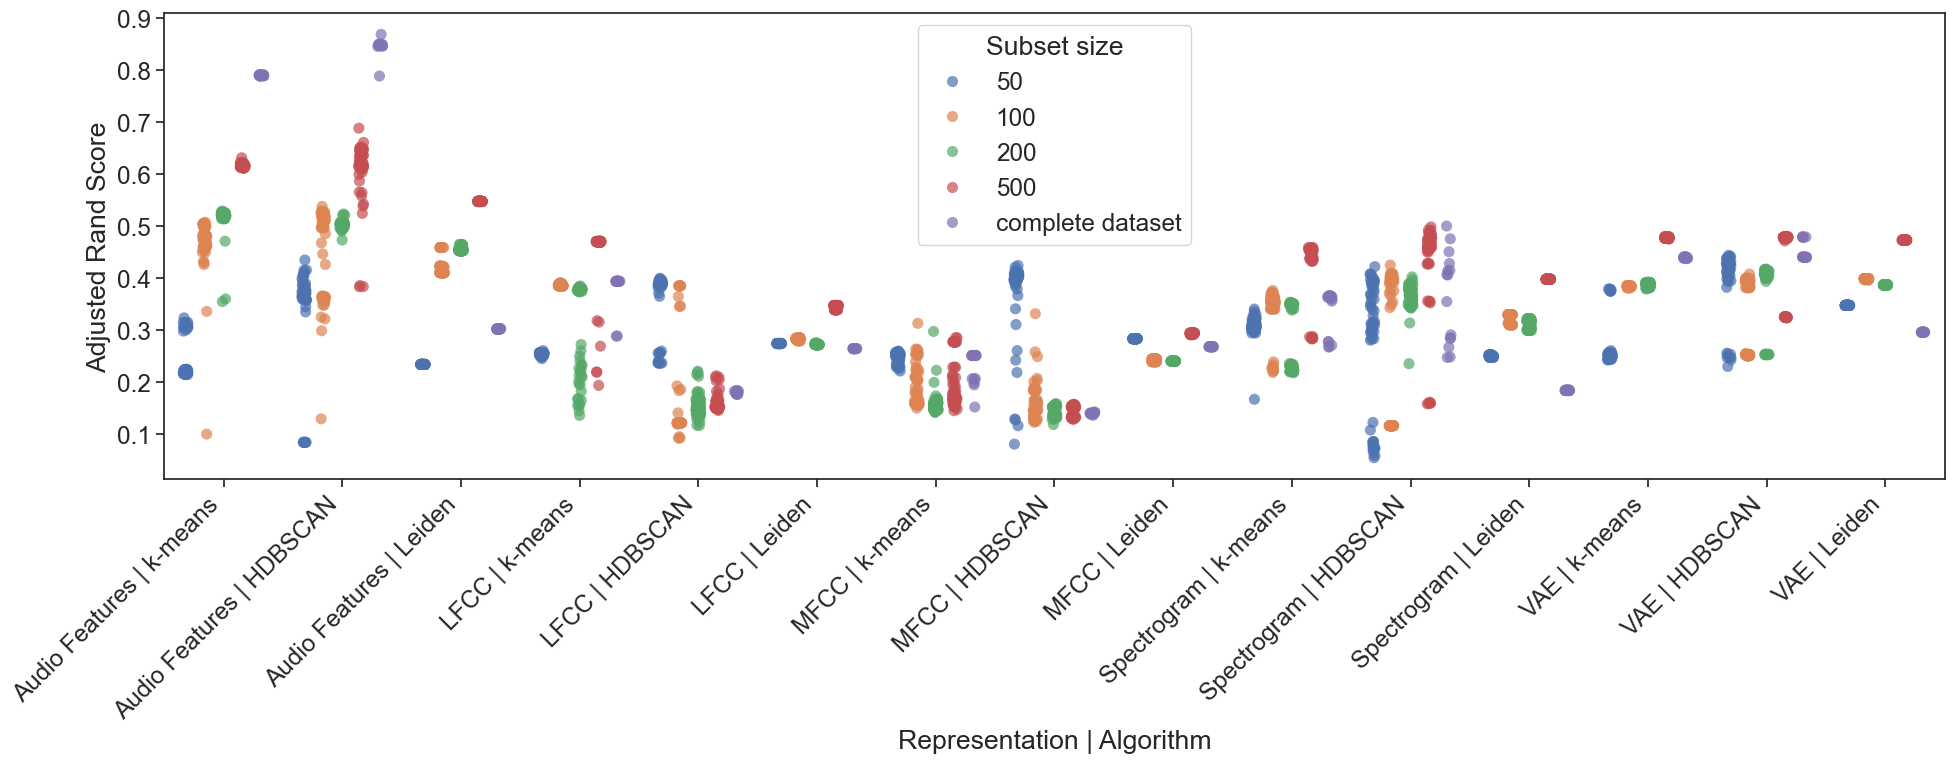

In [156]:
rows: list[str] = ["Adj. RS"]
columns: list[str] = ["k-means", "HDBSCAN", "Leiden"]
representations: list[str] = ["PAF", "LFCC", "Spectrogram", "VAE"]
sub_df = results_df.copy()
sub_df["Rep_Algo"] = sub_df["Representation"] + " | " + sub_df["Algorithm"]


fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 8), sharex=True, sharey=True)

sns.stripplot(
    x="Rep_Algo", 
    y="Adj. RS",  
    data=sub_df, 
    ax=axs, 
    hue="Subset size",
    alpha=.7,
    dodge=0.0001,
    legend=True,
    size=8,
)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Representation | Algorithm")
plt.ylabel("Adjusted Rand Score")

plt.tight_layout()
plt.show()

# Raw numbers

In [157]:
sub_df = results_df[(results_df['Dimensionality']==20)]

In [158]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].min())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].max())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].mean())
    print(sub_df[sub_df["Representation"]==rep]["N clusters"].std())

Audio Features
2
21
4.862745098039215
1.7969747964345941
LFCC
2
25
7.3882352941176475
7.110645425670975
Spectrogram
2
14
3.2745098039215685
1.2592716206868495
VAE
2
4
2.803921568627451
0.4075859333157853


In [159]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
22
4.99764705882353
4.812277352619543
  Audio Features
7
2
4.2823529411764705
1.2306769788740393
  LFCC
12
2
2.9411764705882355
1.4667175952451386
  Spectrogram
3
2
2.835294117647059
0.3731161833457641
  VAE
3
2
2.7058823529411766
0.4583492485141057
HDBSCAN
2
28
8.268235294117646
8.355517493609568
  Audio Features
21
2
4.6
2.1280440382124213
  LFCC
25
2
12.811764705882354
9.78883489059889
  Spectrogram
14
2
3.2823529411764705
1.9248485698378257
  VAE
3
2
2.6941176470588237
0.4635147660812438
Leiden
3
11
5.341176470588235
2.524189301839411
  Audio Features
7
3
5.705882352941177
1.6096696600749563
  LFCC
8
3
6.411764705882353
2.0429560611494106
  Spectrogram
5
3
3.7058823529411766
0.7531446678801509
  VAE
4
3
3.011764705882353
0.1084652289093281


In [160]:
sub_df = results_df

for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["N clusters"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["N clusters"].std())

k-means
2
25
5.294117647058823
5.262549916038932
  Audio Features
7
2
4.1647058823529415
1.293658598948947
  LFCC
22
2
3.9450980392156865
3.765378635659106
  Spectrogram
3
2
2.764705882352941
0.42501668768153256
  VAE
3
2
2.7333333333333334
0.4430862887943897
HDBSCAN
2
57
9.312941176470588
10.114421386941144
  Audio Features
47
2
4.921568627450981
3.238809548815749
  LFCC
45
2
13.95686274509804
10.503191395426484
  Spectrogram
57
2
6.203921568627451
11.409589156417235
  VAE
4
2
2.7294117647058824
0.4624881856959061
Leiden
3
11
5.341960784313725
2.5219452974307934
  Audio Features
7
3
5.705882352941177
1.603319853626784
  LFCC
8
3
6.411764705882353
2.034897031466379
  Spectrogram
5
3
3.7098039215686276
0.7543195562213316
  VAE
4
3
3.011764705882353
0.10803735651599561


In [161]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].mean())
    print(sub_df[sub_df["Representation"]==rep]["V-measure"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["V-measure"].std())

Audio Features
0.5511063677132024
0.1061829361337477
  k-means
   0.5683044103770397
   0.1056263538590241
  HDBSCAN
   0.5932814902730432
   0.08628409080892234
  Leiden
   0.49173320248952435
   0.09843588018283127
LFCC
0.44733832403284324
0.07825494888385436
  k-means
   0.4991708857372844
   0.07790031324544497
  HDBSCAN
   0.4066783843238287
   0.08328666386884442
  Leiden
   0.43616570203741667
   0.030534455913431867
Spectrogram
0.464075839602309
0.08487588543480809
  k-means
   0.4680565091513301
   0.07271792872322443
  HDBSCAN
   0.5022604539923764
   0.09025490733297256
  Leiden
   0.4219105556632205
   0.07049824078395561
VAE
0.5242565379357914
0.05838883773404783
  k-means
   0.5170249613747954
   0.05893871662865986
  HDBSCAN
   0.534445309540668
   0.06636172474815852
  Leiden
   0.5212993428919107
   0.04702618454821852


In [162]:
for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
    print(rep)
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].mean())
    print(sub_df[sub_df["Representation"]==rep]["Adj. RS"].std())
    for algo in ["k-means", "HDBSCAN", "Leiden"]:
        print("  "+algo)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].mean())
        print("  ",sub_sub_df[sub_sub_df["Algorithm"]==algo]["Adj. RS"].std())

Audio Features
0.4633032400016531
0.1431428252821827
  k-means
   0.48440846232673385
   0.15240008268320812
  HDBSCAN
   0.49805343616194997
   0.14353409369243714
  Leiden
   0.4074478215162755
   0.1140679472025172
LFCC
0.28379189007354455
0.09941163202609861
  k-means
   0.35108967070897834
   0.09098327153876169
  HDBSCAN
   0.2081073520061977
   0.10080992580363776
  Leiden
   0.29217864750545747
   0.030283652040900996
Spectrogram
0.3295947969398957
0.09106420782365027
  k-means
   0.3413614407802501
   0.07094131249155622
  HDBSCAN
   0.33458417560534565
   0.12564604109005506
  Leiden
   0.3128387744340912
   0.060645763095870726
VAE
0.3895623156138255
0.06876380714821331
  k-means
   0.3822642600863476
   0.07727322454499769
  HDBSCAN
   0.39093759958509927
   0.07474212645599729
  Leiden
   0.39548508717002945
   0.05073944531727587


In [163]:
for algo in ["k-means", "HDBSCAN", "Leiden"]:
    print(algo)
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].min())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].max())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].mean())
    print(sub_df[sub_df["Algorithm"]==algo]["Adj. RS"].std())
    
    for rep in ["Audio Features", "LFCC", "Spectrogram", "VAE"]:
        print("  "+rep)
        sub_sub_df = sub_df[sub_df["Representation"]==rep]
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].max())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].min())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].mean())
        print(sub_sub_df[(sub_sub_df["Algorithm"]==algo)]["Adj. RS"].std())

k-means
0.10031606535718483
0.7913694430046565
0.3520809794084949
0.13094894928370396
  Audio Features
0.7913694430046565
0.10031606535718483
0.48440846232673385
0.15240008268320812
  LFCC
0.4709732732232156
0.13617466626585167
0.35108967070897834
0.09098327153876169
  Spectrogram
0.45915032601163697
0.1671680489601147
0.3413614407802501
0.07094131249155622
  VAE
0.4802098314709752
0.24299381018976074
0.3822642600863476
0.07727322454499769
HDBSCAN
0.054949879157176015
0.8686192730872303
0.3265045449988049
0.15890087060145283
  Audio Features
0.8686192730872303
0.08446879849507004
0.49805343616194997
0.14353409369243714
  LFCC
0.3998506851280208
0.09250151809053751
0.2081073520061977
0.10080992580363776
  Spectrogram
0.5001995386227764
0.054949879157176015
0.33458417560534565
0.12564604109005506
  VAE
0.48076178835183797
0.23021689133425036
0.39093759958509927
0.07474212645599729
Leiden
0.1838724284681067
0.5492761819314789
0.33470955519930523
0.08568350854763158
  Audio Features
0.5492

In [164]:
!pip install statsmodels

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:              V_measure   No. Observations:                 3825
Model:                            GLM   Df Residuals:                     3812
Model Family:                   Gamma   Df Model:                           12
Link Function:                    log   Scale:                        0.021976
Method:                          IRLS   Log-Likelihood:                 4667.6
Date:                Fri, 24 Oct 2025   Deviance:                       88.022
Time:                        15:17:58   Pearson chi2:                     83.8
No. Iterations:                    12   Pseudo R-squ. (CS):             0.5197
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

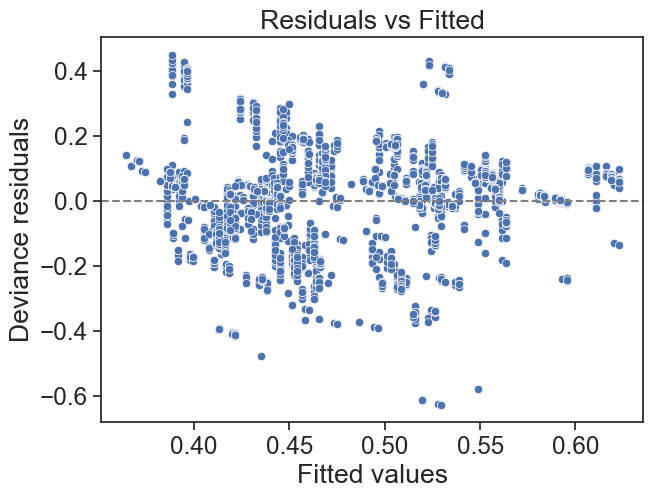

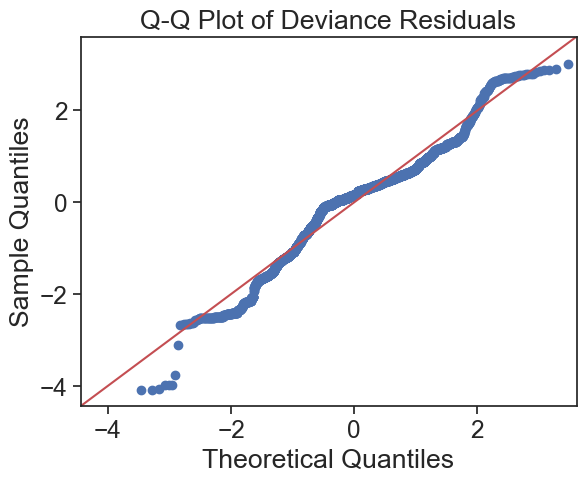

In [165]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

results_without_preset = results_df.copy()[~(results_df["Algorithm"].isin(["k-means-preset", "Leiden-preset"]))]

results_without_preset.rename(columns={'Subset size': 'Subset_size', 'V-measure': 'V_measure', 'Adj. RS': 'Adj_RS', 'Distance metric': 'distance_metric'}, inplace=True)

formula = "V_measure ~ C(Representation) + C(Algorithm) + C(Subset_size) + C(Dimensionality)"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Gamma(link=sm.families.links.log())).fit()
print(glm_beta.summary())

residuals = glm_beta.resid_deviance.copy()
fitted = glm_beta.fittedvalues.copy()

# Residuals vs Fitted
plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Deviance Residuals")
plt.show()

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 Adj_RS   No. Observations:                 3825
Model:                            GLM   Df Residuals:                     3812
Model Family:                   Gamma   Df Model:                           12
Link Function:                    log   Scale:                        0.080239
Method:                          IRLS   Log-Likelihood:                 3591.8
Date:                Fri, 24 Oct 2025   Deviance:                       346.09
Time:                        15:17:58   Pearson chi2:                     306.
No. Iterations:                    17   Pseudo R-squ. (CS):             0.5969
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

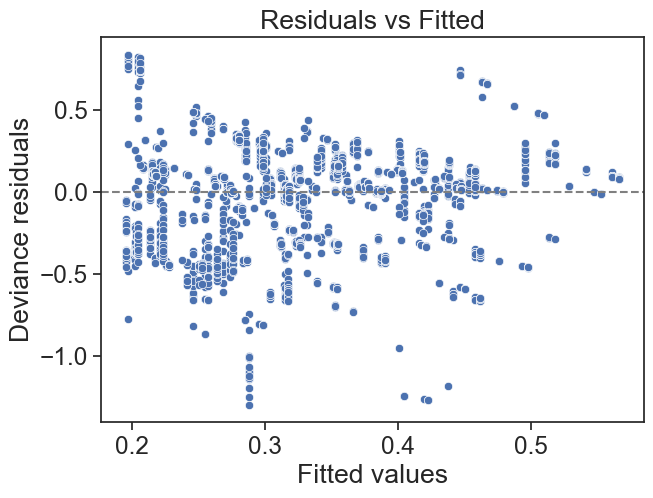

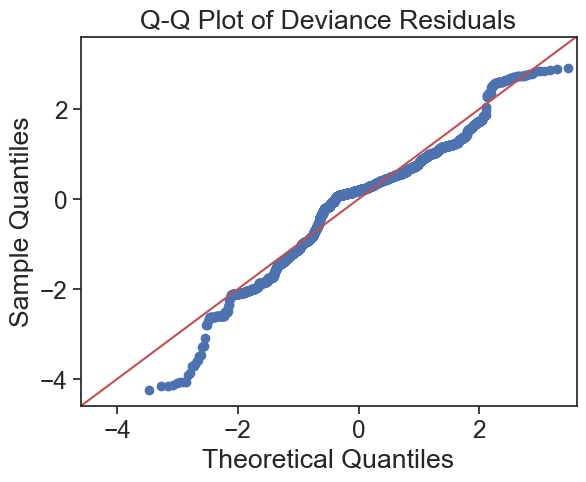

In [166]:
formula = "Adj_RS ~ C(Representation) + C(Algorithm) + C(Subset_size) + C(Dimensionality)"
glm_beta = smf.glm(formula, data=results_without_preset,
                    family=sm.families.Gamma(link=sm.families.links.log())).fit()
print(glm_beta.summary())

residuals = glm_beta.resid_deviance.copy()
fitted = glm_beta.fittedvalues.copy()

# Residuals vs Fitted
plt.figure(figsize=(7, 5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Deviance residuals")
plt.title("Residuals vs Fitted")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Deviance Residuals")
plt.show()
